# PPG 自适应滤波批处理实验 Notebook

本 notebook 用于按运动类型批量评估 PPG 心率估计流程，包括数据发现、质量检查、全局 Tdelay 静息段对齐诊断、未对齐 PPG-HR 测试图、Optuna 参数搜索、结果检查和手动重画 HR 曲线。

重要约定：

- `Alignment_TW` 只用于静息段 PPG-HR 提取和全局 Tdelay 搜索，不参与 Optuna 搜索。
- `TW` 只用于后续训练、验证、测试窗口切分，可以由 Optuna 或训练配置控制。
- 静息段 PPG-HR 的非 Optuna 参数统一放在第一个代码块，后续诊断图和训练流程默认复用这些参数。
- 若心率曲线异常，建议先看第 3、4、6 部分的诊断图，再调整第一个代码块中的静息 HR 参数。


In [1]:
# 0. 初始化路径、依赖和全局默认参数
# 本单元只做一次 notebook 级初始化：配置项目路径、导入函数、建立输出目录，并集中设置训练和静息 HR 提取参数。
# 后续单元默认读取这里定义的全局变量；如果需要调整静息段 PPG-HR 行为，优先修改本单元中的 REST_HR_* 参数。
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

# 项目根目录、源码目录、测试数据目录和输出目录。
# 注意：如果项目目录移动，需要同步修改 PROJECT_ROOT。
PROJECT_ROOT = Path(r"D:\python_notebook_base")
SRC_DIR = PROJECT_ROOT / "src"
TESTDATA_DIR = PROJECT_ROOT / "testdata"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"

assert PROJECT_ROOT.exists(), f"项目根目录不存在: {PROJECT_ROOT}"
assert SRC_DIR.exists(), f"源码目录不存在: {SRC_DIR}"
assert TESTDATA_DIR.exists(), f"测试数据目录不存在: {TESTDATA_DIR}"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Optuna 用于贝叶斯超参数搜索；如果当前环境未安装，批处理代码会使用已有 fallback 逻辑。
try:
    import optuna
    print("optuna", optuna.__version__)
except ModuleNotFoundError:
    optuna = None
    print("未安装 optuna，训练时会使用项目内置 fallback。")

from ppg_hr.experimental.alignment import align_ppg_to_ref_hr
from ppg_hr.experimental.batch_pairing import discover_sample_pairs_with_unpaired
from ppg_hr.experimental.preprocess_protocol import load_and_preprocess_protocol, resample_protocol_dataset
from ppg_hr.experimental.qc import quality_filter_sample
from ppg_hr.experimental.protocol_outputs import (
    plot_rest_alignment_diagnostics_by_motion_type,
    plot_raw_ppg_and_unaligned_hr_by_motion_type,
    plot_unaligned_fullfield_ppg_hr_by_motion_type,
)
from ppg_hr.experimental.run_batch_protocol import (
    build_output_run_name,
    redraw_best_param_hr_curves,
    run_batch_adaptive_protocol,
    safe_prepare_output_dir,
)
from ppg_hr.experimental.segmentation import detect_activity_segments
from ppg_hr.params import ProtocolSearchParams

# -----------------------------
# 批处理与数据划分默认参数
# -----------------------------
RANDOM_STATE = 42
FS_ORIGIN = 100
CLEAN_OUTPUTS = False
OPTIMIZATION_OBJECTIVE = "accuracy"  # 可选 "accuracy" 或 "aae"；accuracy 表示 abs_err <= 5 bpm 的比例。
DATA_SPLIT_MODE = "all_train"  # 可选 "split"、"all_train" 或 "leave_one_group_out"。
VAL_GROUPS_PER_TYPE = 1
TEST_GROUPS_PER_TYPE = 1
DELAY_ESTIMATION_MODE = "envelope"  # 可选 "envelope" 或 "direct"；默认保留 Hilbert 包络旧逻辑。

# -----------------------------
# 静息段 PPG-HR 与全局 Tdelay 的非 Optuna 参数
# -----------------------------
# Alignment_TW 用于静息段 PPG-HR 提取和全局 Tdelay 搜索。
# 它和训练窗口 TW 是两个物理含义不同的参数：Alignment_TW 不参与 Optuna，训练 TW 仍由 ProtocolTrialParams 控制。
ALIGNMENT_TW = 6.0
ALIGNMENT_STEP_S = 1.0
REST_ALIGNMENT_SCORE_MODE = "aae"  # 可选: "aae" 或 "std"


# 静息段 FFT 心率搜索范围。0.5-2 Hz 对应 30-120 bpm，这里保留更宽的 40-180 bpm，便于覆盖异常或高心率样本。
REST_HR_BAND_BPM = (40.0, 180.0)
REST_HR_BAND_HZ = tuple(v / 60.0 for v in REST_HR_BAND_BPM)

# 静息段 HR 后处理参数：
# track_band 控制从上一 HR 附近多宽的范围找候选峰；
# slew_limit/step 用于防止倍频、半频或噪声峰造成 HR 突跳；
# smooth_win 是 moving median 平滑窗口，建议使用奇数。
REST_HR_TRACK_BAND_BPM = 30.0
REST_HR_SLEW_LIMIT_BPM = 4.0
REST_HR_SLEW_STEP_BPM = 2.0
REST_HR_SMOOTH_METHOD = "median"
REST_HR_SMOOTH_WIN = 7
REST_HR_PEAK_PERCENT = 0.3

# 频谱运动惩罚参数：启用后会参考 ACC 频谱，对运动频率及其倍频附近的 PPG 峰做轻度惩罚。
# 如果静息段 ACC 噪声较大导致 HR 被压错，可先把 REST_HR_SPEC_PENALTY_ENABLE 改为 False 对比。
REST_HR_SPEC_PENALTY_ENABLE = True
REST_HR_SPEC_PENALTY_WEIGHT = 0.2
REST_HR_SPEC_PENALTY_WIDTH_HZ = 0.2

# 自适应滤波 HR 曲线生成后的后处理对齐，仅用于诊断评价和绘图。
# time_bias_after_s = b 表示参考 HR 在 t_pred_s + b 处取样；b > 0 等价于绘图时参考曲线左移 b 秒。
ENABLE_TIME_BIAS_AFTER = True
TIME_BIAS_AFTER_RANGE_S = (-5.0, 5.0)
TIME_BIAS_AFTER_STEP_S = 1.0
TIME_BIAS_AFTER_MODE = "posthoc_oracle_alignment"

# REST_HR_KWARGS 直接传给静息段诊断绘图函数；
# REST_HR_TRIAL_OVERRIDES 传给 ProtocolTrialParams，用于训练流程中的全局对齐和缓存 key。
REST_HR_KWARGS = {
    "hr_band_bpm": REST_HR_BAND_BPM,
    "track_band_bpm": REST_HR_TRACK_BAND_BPM,
    "slew_limit_bpm": REST_HR_SLEW_LIMIT_BPM,
    "slew_step_bpm": REST_HR_SLEW_STEP_BPM,
    "smooth_method": REST_HR_SMOOTH_METHOD,
    "smooth_win": REST_HR_SMOOTH_WIN,
    "peak_percent": REST_HR_PEAK_PERCENT,
    "spec_penalty_enable": REST_HR_SPEC_PENALTY_ENABLE,
    "spec_penalty_weight": REST_HR_SPEC_PENALTY_WEIGHT,
    "spec_penalty_width_hz": REST_HR_SPEC_PENALTY_WIDTH_HZ,
}
REST_HR_TRIAL_OVERRIDES = {
    "Alignment_TW": ALIGNMENT_TW,
    "Alignment_Step": ALIGNMENT_STEP_S,
    "Rest_HR_Band_BPM": REST_HR_BAND_BPM,
    "Rest_HR_Track_Band_BPM": REST_HR_TRACK_BAND_BPM,
    "Rest_HR_Slew_Limit_BPM": REST_HR_SLEW_LIMIT_BPM,
    "Rest_HR_Slew_Step_BPM": REST_HR_SLEW_STEP_BPM,
    "Rest_HR_Smooth_Method": REST_HR_SMOOTH_METHOD,
    "Rest_HR_Smooth_Win": REST_HR_SMOOTH_WIN,
    "Rest_HR_Peak_Percent": REST_HR_PEAK_PERCENT,
    "Rest_HR_Spec_Penalty_Enable": REST_HR_SPEC_PENALTY_ENABLE,
    "Rest_HR_Spec_Penalty_Weight": REST_HR_SPEC_PENALTY_WEIGHT,
    "Rest_HR_Spec_Penalty_Width_Hz": REST_HR_SPEC_PENALTY_WIDTH_HZ,
    "Rest_Alignment_Score_Mode": REST_ALIGNMENT_SCORE_MODE,
    "Enable_Time_Bias_After": ENABLE_TIME_BIAS_AFTER,
    "Time_Bias_After_Range_S": TIME_BIAS_AFTER_RANGE_S,
    "Time_Bias_After_Step_S": TIME_BIAS_AFTER_STEP_S,
    "Time_Bias_After_Mode": TIME_BIAS_AFTER_MODE,
}

# 默认训练组合。调试 notebook 时可以先保留较少组合，正式运行时再在训练单元覆盖。
ACTIVE_TARGET_SCOPES = ["motion_only"]
ACTIVE_CASCADE_SCHEMES = ["ACC3", "HF2"]
ACTIVE_ADAPTIVE_FILTERS = ["lms"]
CASCADE_TRAIN_BUDGETS = {scheme: {"n_trials": 1, "n_repeats": 1} for scheme in ACTIVE_CASCADE_SCHEMES}

def make_unique_output_dir(target_scopes, cascade_schemes, adaptive_filters, objective_mode, split_mode):
    '''根据当前训练配置创建唯一输出目录，避免覆盖已有实验结果。'''
    base_name = build_output_run_name(target_scopes, cascade_schemes, adaptive_filters, objective_mode, split_mode)
    run_name = base_name
    run_dir = OUTPUT_ROOT / run_name
    if not CLEAN_OUTPUTS:
        idx = 1
        while run_dir.exists() and any(run_dir.iterdir()):
            run_name = f"{base_name}__run{idx:02d}"
            run_dir = OUTPUT_ROOT / run_name
            idx += 1
    run_dir = safe_prepare_output_dir(project_root=PROJECT_ROOT, output_dir=run_dir, clean_outputs=CLEAN_OUTPUTS)
    return run_name, run_dir

OUTPUT_RUN_NAME, RUN_OUTPUT_DIR = make_unique_output_dir(
    ACTIVE_TARGET_SCOPES,
    ACTIVE_CASCADE_SCHEMES,
    ACTIVE_ADAPTIVE_FILTERS,
    OPTIMIZATION_OBJECTIVE,
    DATA_SPLIT_MODE,
)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)
print("TESTDATA_DIR:", TESTDATA_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("OUTPUT_RUN_NAME:", OUTPUT_RUN_NAME)
print("RUN_OUTPUT_DIR:", RUN_OUTPUT_DIR)
print("REST_HR_TRIAL_OVERRIDES:", REST_HR_TRIAL_OVERRIDES)


optuna 4.8.0
PROJECT_ROOT: D:\python_notebook_base
SRC_DIR: D:\python_notebook_base\src
TESTDATA_DIR: D:\python_notebook_base\testdata
OUTPUT_ROOT: D:\python_notebook_base\outputs
OUTPUT_RUN_NAME: motion_only__ACC3-HF2__lms__accuracy__all_train
RUN_OUTPUT_DIR: D:\python_notebook_base\outputs\motion_only__ACC3-HF2__lms__accuracy__all_train
REST_HR_TRIAL_OVERRIDES: {'Alignment_TW': 6.0, 'Alignment_Step': 1.0, 'Rest_HR_Band_BPM': (40.0, 180.0), 'Rest_HR_Track_Band_BPM': 30.0, 'Rest_HR_Slew_Limit_BPM': 4.0, 'Rest_HR_Slew_Step_BPM': 2.0, 'Rest_HR_Smooth_Method': 'median', 'Rest_HR_Smooth_Win': 7, 'Rest_HR_Peak_Percent': 0.3, 'Rest_HR_Spec_Penalty_Enable': True, 'Rest_HR_Spec_Penalty_Weight': 0.2, 'Rest_HR_Spec_Penalty_Width_Hz': 0.2, 'Rest_Alignment_Score_Mode': 'aae', 'Enable_Time_Bias_After': True, 'Time_Bias_After_Range_S': (-5.0, 5.0), 'Time_Bias_After_Step_S': 1.0, 'Time_Bias_After_Mode': 'posthoc_oracle_alignment'}


## 1. 发现样本配对并执行 QC

本部分读取 `testdata` 中的 `multi_<运动名+编号>.csv` 与对应 `_ref.csv` 文件，建立样本配对并进行基础质量检查。

输出对象：

- `pairs_df`：所有成功配对的样本清单。
- `unpaired_df`：未找到对应传感器文件或参考文件的异常样本。
- `good_pairs`：通过 QC 的样本，后续训练和绘图默认使用它。
- `bad_pairs` / `qc_df`：未通过 QC 的样本及原因。


In [2]:
# 从 testdata 中发现传感器 CSV 与参考 HR CSV 的配对关系。
discovery = discover_sample_pairs_with_unpaired(TESTDATA_DIR)

# pairs_df 用于快速检查每个 motion_type 下有哪些 group_id 和文件名。
pairs_df = pd.DataFrame([
    {
        "group_id": p.motion_id,
        "motion_type": p.motion_type,
        "motion_index": p.motion_index,
        "data_file": p.sensor_csv.name,
        "ref_file": p.ref_csv.name,
    }
    for p in discovery.pairs
])

# unpaired_df 用于发现命名不匹配、缺少 ref 或缺少 sensor 的文件。
unpaired_df = pd.DataFrame([
    {"file_name": u.file_name, "file_path": str(u.file_path), "reason": u.reason}
    for u in discovery.unpaired
])

# 对每个配对样本执行质量检查；只有 good_pairs 会进入后续训练与诊断绘图。
qc_rows = []
good_pairs = []
bad_pairs = []
for pair in discovery.pairs:
    qc = quality_filter_sample(
        pair.sensor_csv,
        fs=FS_ORIGIN,
        group_id=pair.motion_id,
        motion_type=pair.motion_type,
        ref_csv=pair.ref_csv,
    )
    qc_rows.append(qc.to_dict())
    if qc.is_good:
        good_pairs.append(pair)
    else:
        bad_pairs.append(pair)
qc_df = pd.DataFrame(qc_rows)

print("已配对样本数:", len(discovery.pairs))
print("未配对文件数:", len(discovery.unpaired))
print("通过 QC 样本数:", len(good_pairs))
print("未通过 QC 样本数:", len(bad_pairs))
print("检测到的运动类型:", sorted(pairs_df["motion_type"].unique()) if not pairs_df.empty else [])
if not pairs_df.empty:
    display(pairs_df.groupby("motion_type")[["group_id", "data_file"]].agg(list).reset_index())
display(pairs_df)
display(unpaired_df)
display(qc_df)


已配对样本数: 28
未配对文件数: 0
通过 QC 样本数: 28
未通过 QC 样本数: 0
检测到的运动类型: ['bobi', 'fuwo', 'kaihe', 'tiaosheng', 'wanju']


,motion_type,group_id,data_file
0,bobi,"[bobi1, bobi2, bobi3, bobi4, bobi5, bobi6]","[multi_bobi1.csv, multi_bobi2.csv, multi_bobi3..."
1,fuwo,"[fuwo1, fuwo2, fuwo3, fuwo4, fuwo5]","[multi_fuwo1.csv, multi_fuwo2.csv, multi_fuwo3..."
2,kaihe,"[kaihe1, kaihe2, kaihe3, kaihe4, kaihe5]","[multi_kaihe1.csv, multi_kaihe2.csv, multi_kai..."
3,tiaosheng,"[tiaosheng1, tiaosheng2, tiaosheng3, tiaosheng...","[multi_tiaosheng1.csv, multi_tiaosheng2.csv, m..."
4,wanju,"[wanju1, wanju2, wanju3, wanju4, wanju5]","[multi_wanju1.csv, multi_wanju2.csv, multi_wan..."


,group_id,motion_type,motion_index,data_file,ref_file
0,bobi1,bobi,1,multi_bobi1.csv,multi_bobi1_ref.csv
1,bobi2,bobi,2,multi_bobi2.csv,multi_bobi2_ref.csv
2,bobi3,bobi,3,multi_bobi3.csv,multi_bobi3_ref.csv
3,bobi4,bobi,4,multi_bobi4.csv,multi_bobi4_ref.csv
4,bobi5,bobi,5,multi_bobi5.csv,multi_bobi5_ref.csv
5,bobi6,bobi,6,multi_bobi6.csv,multi_bobi6_ref.csv
6,fuwo1,fuwo,1,multi_fuwo1.csv,multi_fuwo1_ref.csv
7,fuwo2,fuwo,2,multi_fuwo2.csv,multi_fuwo2_ref.csv
8,fuwo3,fuwo,3,multi_fuwo3.csv,multi_fuwo3_ref.csv
9,fuwo4,fuwo,4,multi_fuwo4.csv,multi_fuwo4_ref.csv


""


,group_id,motion_type,data_file,ref_file,file_name,status,reason,std_ut1,std_ut2,outlier_count_ut1,outlier_count_ut2,outlier_ratio_ut1,outlier_ratio_ut2,is_good
0,bobi1,bobi,D:\python_notebook_base\testdata\multi_bobi1.csv,D:\python_notebook_base\testdata\multi_bobi1_r...,multi_bobi1.csv,good,ok,0.210996,0.251293,6,5,0.006,0.005,True
1,bobi2,bobi,D:\python_notebook_base\testdata\multi_bobi2.csv,D:\python_notebook_base\testdata\multi_bobi2_r...,multi_bobi2.csv,good,ok,0.189535,0.158103,16,10,0.016,0.010,True
2,bobi3,bobi,D:\python_notebook_base\testdata\multi_bobi3.csv,D:\python_notebook_base\testdata\multi_bobi3_r...,multi_bobi3.csv,good,ok,0.200952,0.196852,5,5,0.005,0.005,True
3,bobi4,bobi,D:\python_notebook_base\testdata\multi_bobi4.csv,D:\python_notebook_base\testdata\multi_bobi4_r...,multi_bobi4.csv,good,ok,0.233646,0.265550,2,7,0.002,0.007,True
4,bobi5,bobi,D:\python_notebook_base\testdata\multi_bobi5.csv,D:\python_notebook_base\testdata\multi_bobi5_r...,multi_bobi5.csv,good,ok,0.151042,0.130527,13,14,0.013,0.014,True
5,bobi6,bobi,D:\python_notebook_base\testdata\multi_bobi6.csv,D:\python_notebook_base\testdata\multi_bobi6_r...,multi_bobi6.csv,good,ok,0.149102,0.213220,8,4,0.008,0.004,True
6,fuwo1,fuwo,D:\python_notebook_base\testdata\multi_fuwo1.csv,D:\python_notebook_base\testdata\multi_fuwo1_r...,multi_fuwo1.csv,good,ok,0.207834,0.365072,8,5,0.008,0.005,True
7,fuwo2,fuwo,D:\python_notebook_base\testdata\multi_fuwo2.csv,D:\python_notebook_base\testdata\multi_fuwo2_r...,multi_fuwo2.csv,good,ok,0.209869,0.167940,17,4,0.017,0.004,True
8,fuwo3,fuwo,D:\python_notebook_base\testdata\multi_fuwo3.csv,D:\python_notebook_base\testdata\multi_fuwo3_r...,multi_fuwo3.csv,good,ok,0.205055,0.152184,26,18,0.026,0.018,True
9,fuwo4,fuwo,D:\python_notebook_base\testdata\multi_fuwo4.csv,D:\python_notebook_base\testdata\multi_fuwo4_r...,multi_fuwo4.csv,good,ok,0.151071,0.091297,10,5,0.010,0.005,True


## 2. 单样本预处理、分段和全局对齐预览

本部分只抽取一个通过 QC 的样本做 smoke preview，用来确认：

- 数据加载和重采样是否正常。
- ACC 分段是否能识别静息、运动和运动恢复。
- `align_ppg_to_ref_hr` 是否使用固定 `ALIGNMENT_TW` 估计 Tdelay。
- 后续训练窗口是否仍使用 `preview_train_TW`，而不是误用 `ALIGNMENT_TW`。


In [3]:
# 只取第一个 good sample 做快速预览，避免在初始化阶段消耗太长时间。
if good_pairs:
    pair = good_pairs[0]
    ds = load_and_preprocess_protocol(pair.sensor_csv, pair.ref_csv, fs_origin=FS_ORIGIN)
    ds = resample_protocol_dataset(ds, fs_target=100)

    # preview_train_TW 模拟训练窗口长度；全局 Tdelay 仍使用第 0 单元定义的 ALIGNMENT_TW。
    preview_train_TW = 8
    seg = detect_activity_segments(ds.accx, ds.accy, ds.accz, ds.fs, TW=preview_train_TW)
    if not seg.is_valid:
        print(f"分段失败: {pair.stem}: {seg.reason}")
    else:
        aligned = align_ppg_to_ref_hr(
            ds,
            seg,
            TW=preview_train_TW,
            fs_target=ds.fs,
            alignment_TW=ALIGNMENT_TW,
            alignment_step_s=ALIGNMENT_STEP_S,
            rest_hr_kwargs=REST_HR_KWARGS,
            alignment_score_mode=REST_ALIGNMENT_SCORE_MODE,
        )
        display(pd.DataFrame([{
            "sample": pair.stem,
            "motion_type": pair.motion_type,
            "fs": ds.fs,
            "motion_start_s": aligned.segment_info.motion_start_s,
            "motion_end_s": aligned.segment_info.motion_end_s,
            "alignment_TW": aligned.alignment_info.alignment_tw_s,
            "train_TW": aligned.alignment_info.train_tw_s,
            "best_tdelay_s": aligned.alignment_info.best_tdelay_s,
            "num_windows": aligned.alignment_info.num_windows,
            "rest_windows": len(aligned.rest_indices),
            "motion_windows": len(aligned.motion_indices),
            "recovery_windows": len(aligned.recovery_indices),
        }]))
else:
    print("没有通过 QC 的样本，后续训练无法继续。")


[alignment] multi_bobi1: best_tdelay_s=-2.6, rest_windows=76


,sample,motion_type,fs,motion_start_s,motion_end_s,alignment_TW,train_TW,best_tdelay_s,num_windows,rest_windows,motion_windows,recovery_windows
0,multi_bobi1,bobi,100,85.6,149.6,6.0,8.0,-2.6,228,82,64,82


## 3. 全局 Tdelay 静息段对齐诊断图（Alignment_TW=8）

本部分为每个运动类型输出一张静息段对齐诊断图。每个子图对应一组运动，包含：

- 对齐后的参考 HR。
- 使用第 0 单元 `REST_HR_KWARGS` 提取的静息段 PPG FFT HR。

这张图只用于检查全局 Tdelay 是否合理，不参与 Optuna objective，也不会改变训练窗口。


[alignment] multi_bobi2: best_tdelay_s=-3.0, rest_windows=76
[alignment] multi_bobi3: best_tdelay_s=4.8, rest_windows=47
[alignment] multi_bobi4: best_tdelay_s=-2.6, rest_windows=47
[alignment] multi_bobi5: best_tdelay_s=5.0, rest_windows=46
[alignment] multi_bobi6: best_tdelay_s=-3.0, rest_windows=47
[alignment] multi_fuwo1: best_tdelay_s=-2.5, rest_windows=77
[alignment] multi_fuwo2: best_tdelay_s=-2.9, rest_windows=77
[alignment] multi_fuwo3: best_tdelay_s=4.6, rest_windows=47
[alignment] multi_fuwo4: best_tdelay_s=0.9, rest_windows=46
[alignment] multi_fuwo5: best_tdelay_s=4.6, rest_windows=47
[alignment] multi_kaihe1: best_tdelay_s=-2.4, rest_windows=76
[alignment] multi_kaihe2: best_tdelay_s=-2.8, rest_windows=75
[alignment] multi_kaihe3: best_tdelay_s=-2.1, rest_windows=47
[alignment] multi_kaihe4: best_tdelay_s=-3.0, rest_windows=47
[alignment] multi_kaihe5: best_tdelay_s=-3.0, rest_windows=46
[alignment] multi_tiaosheng1: best_tdelay_s=4.1, rest_windows=77
[alignment] multi_ti

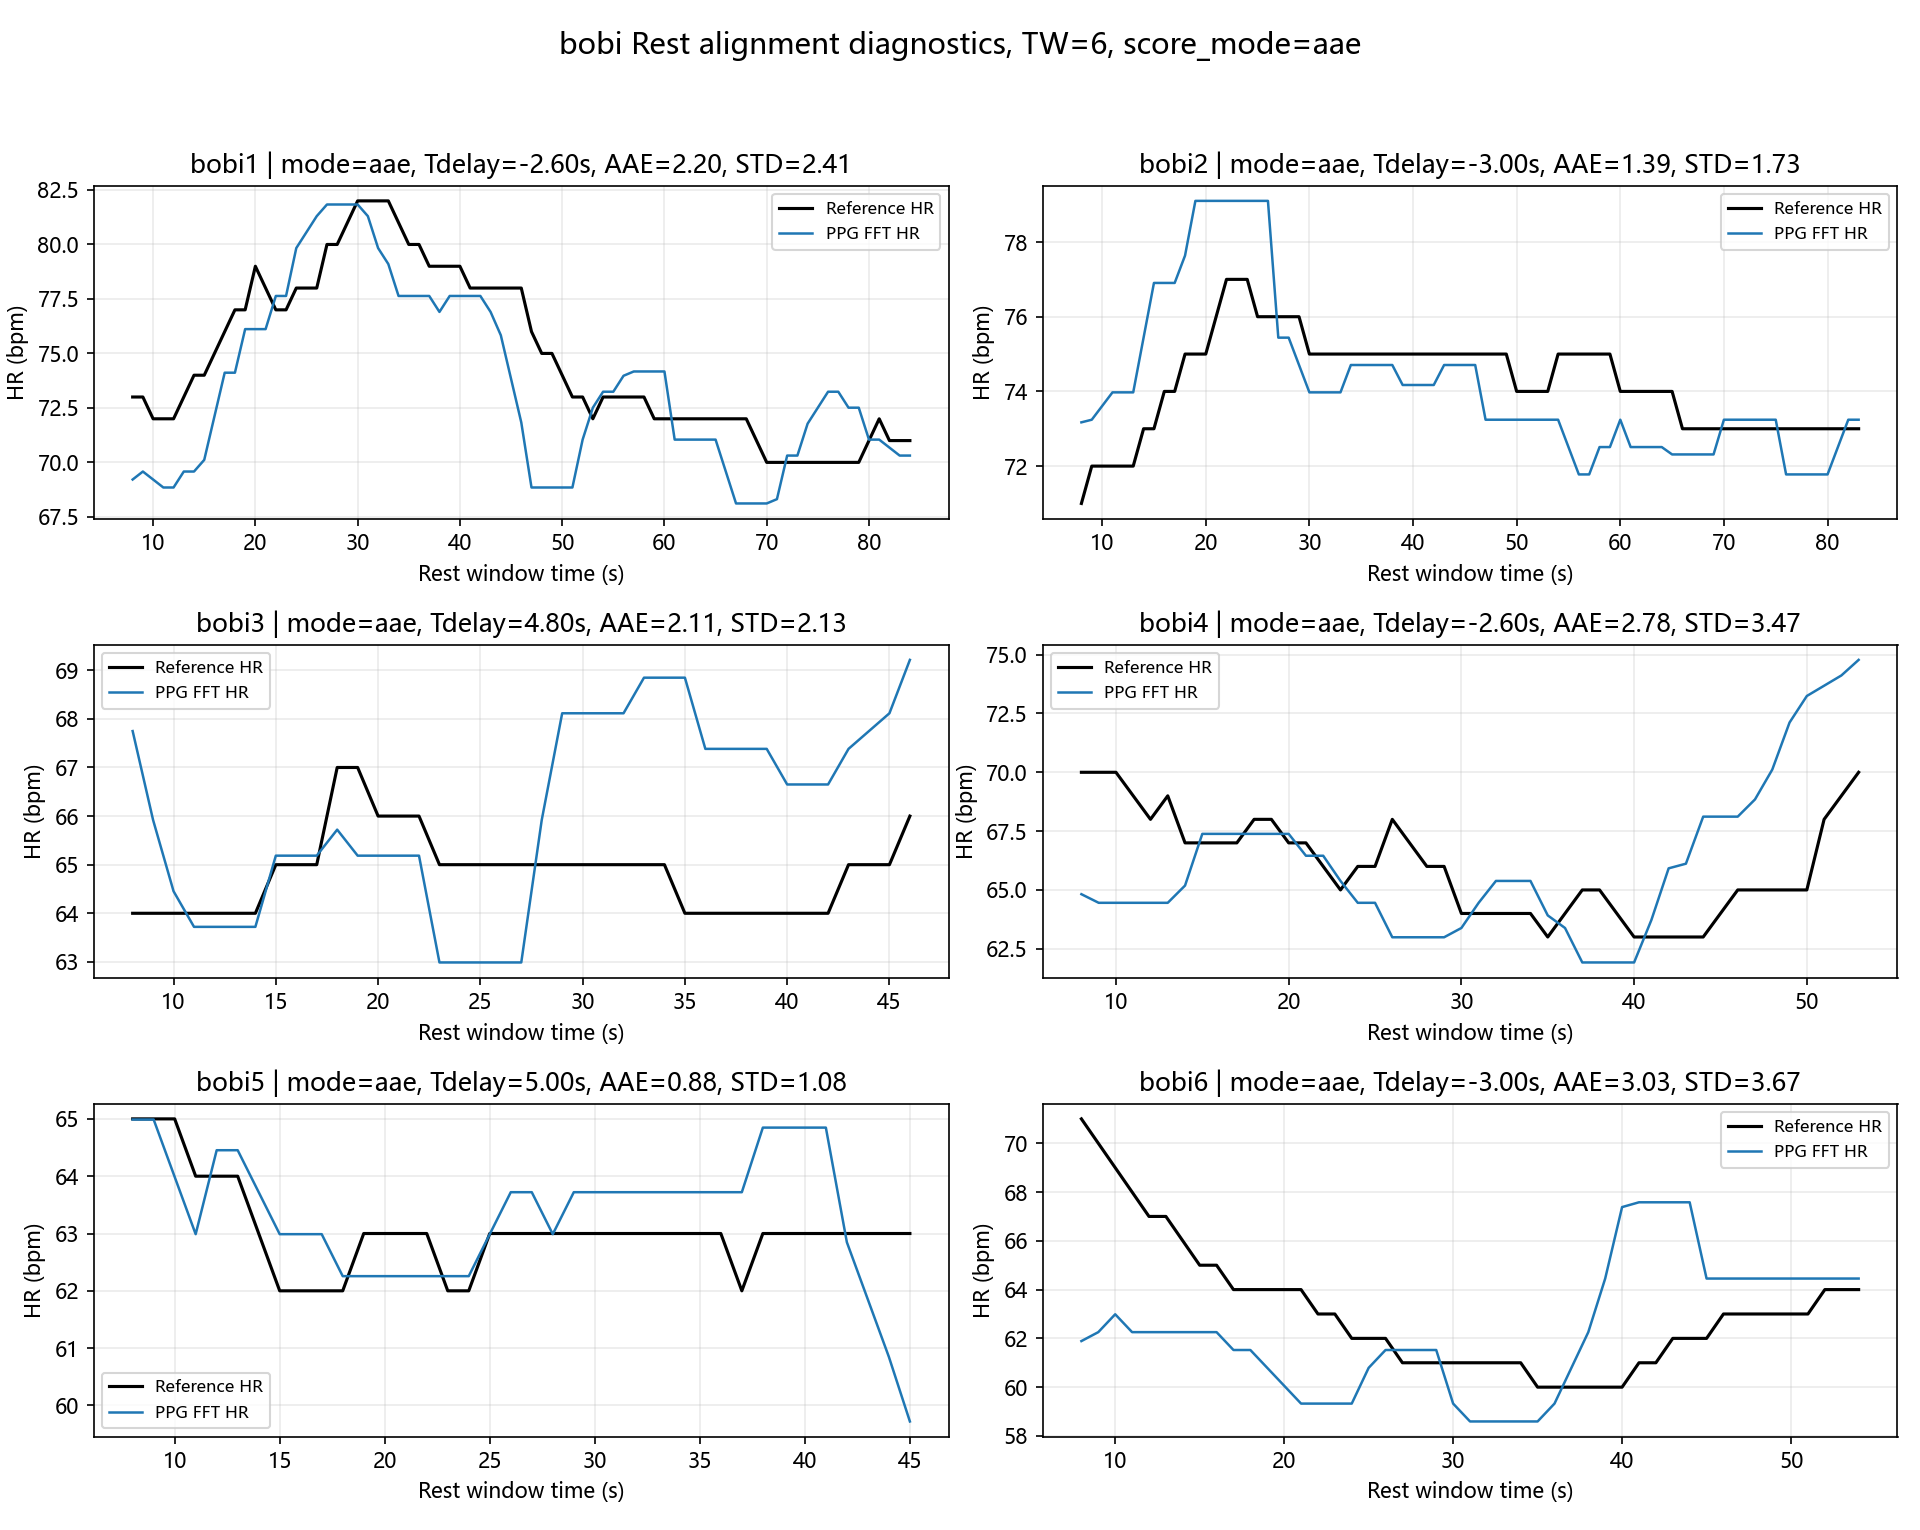

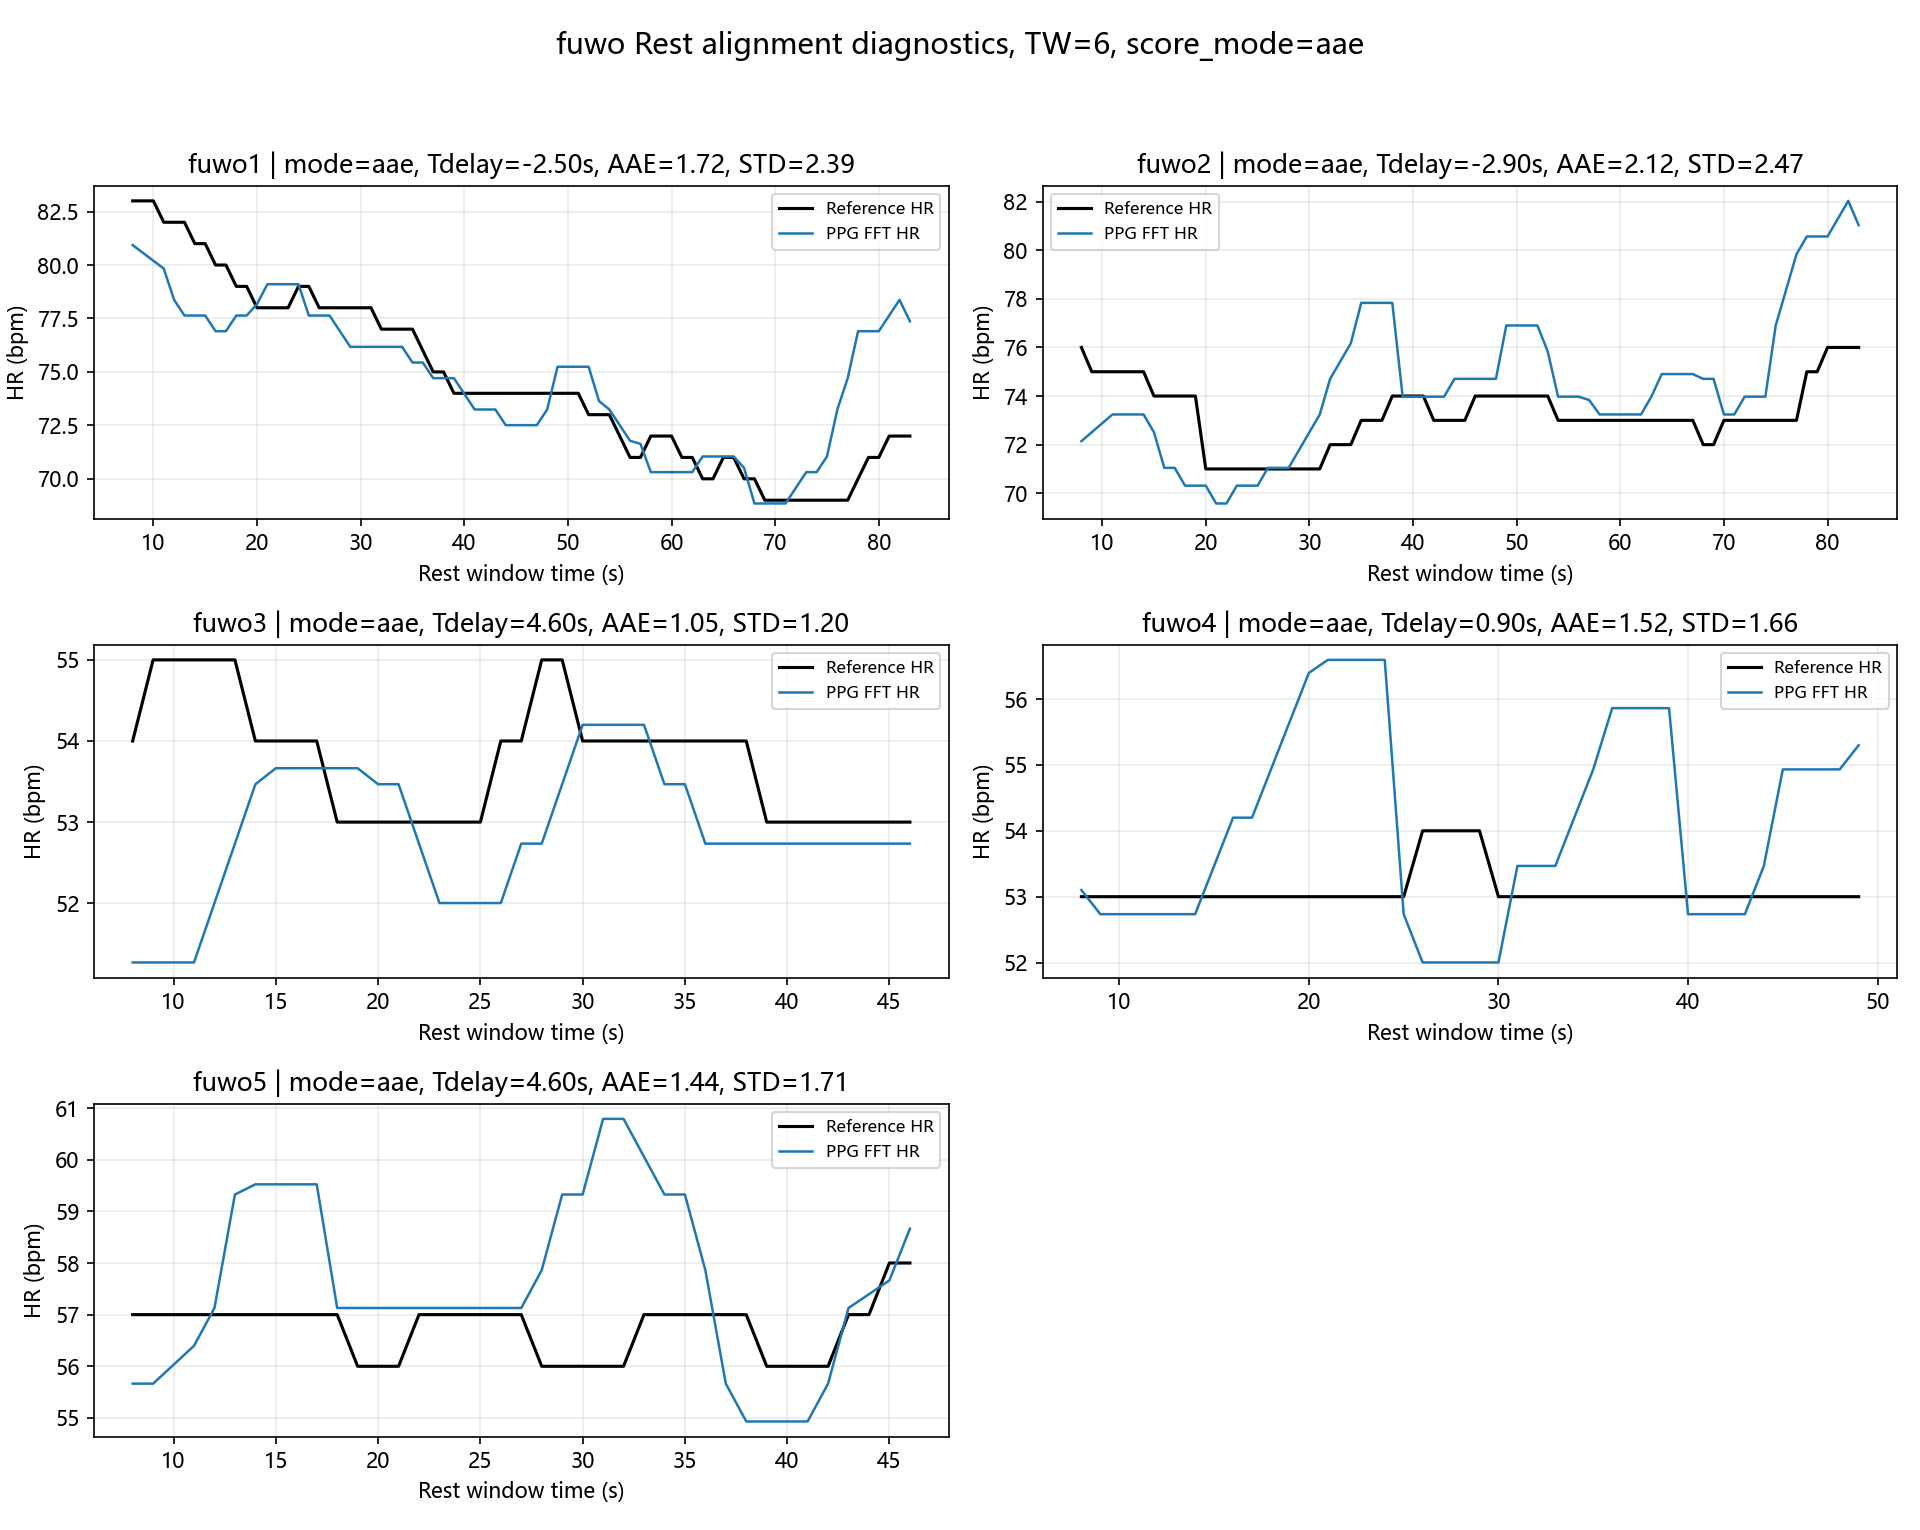

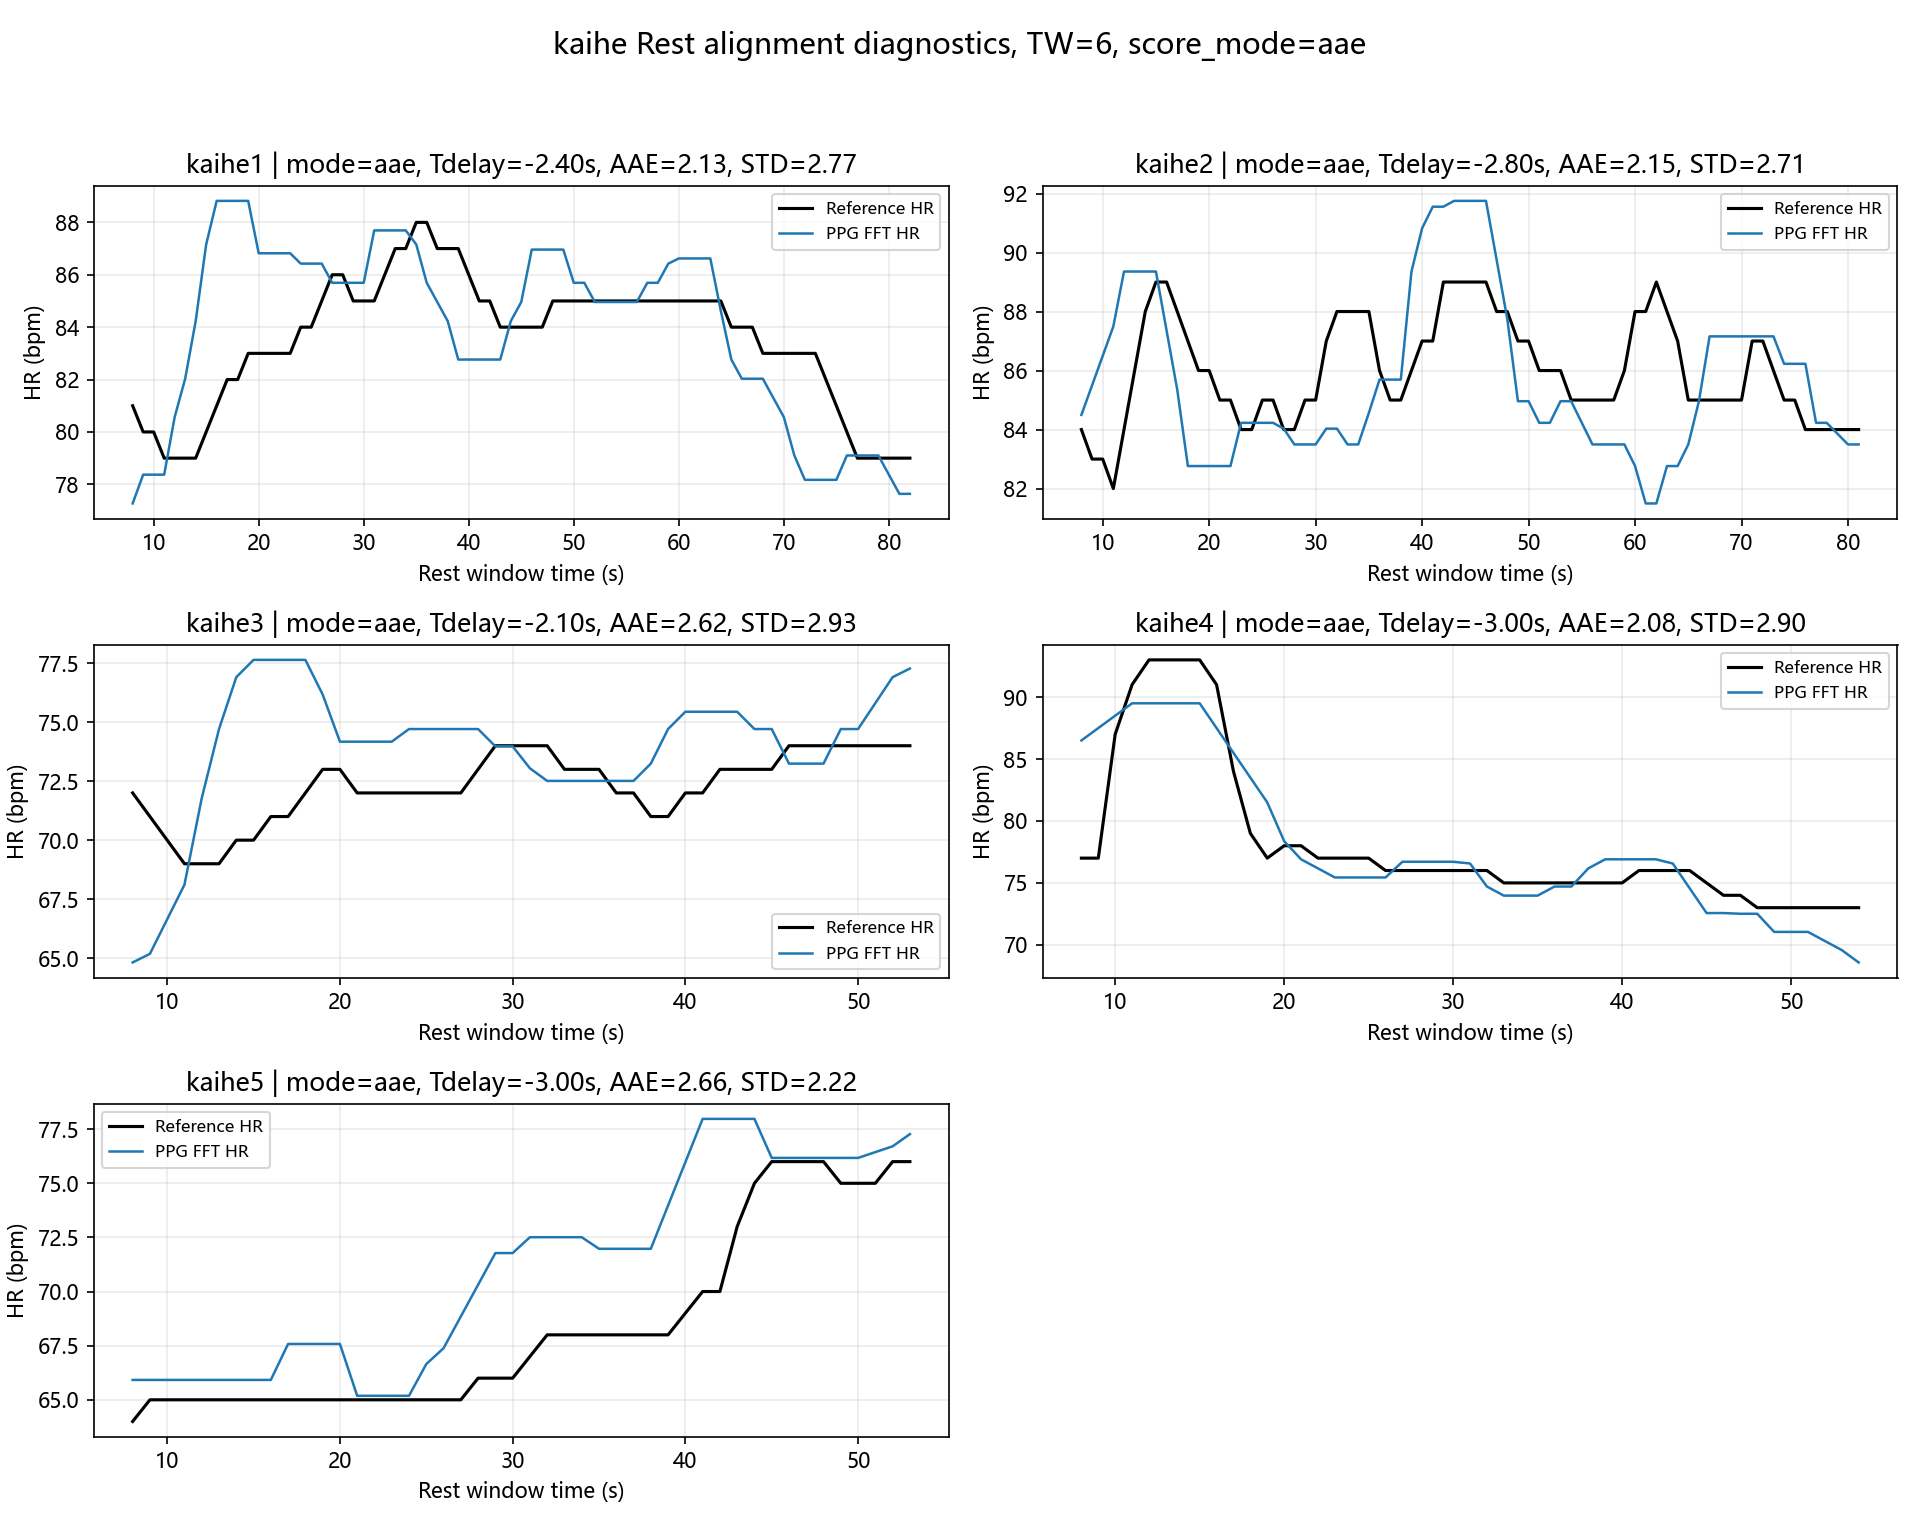

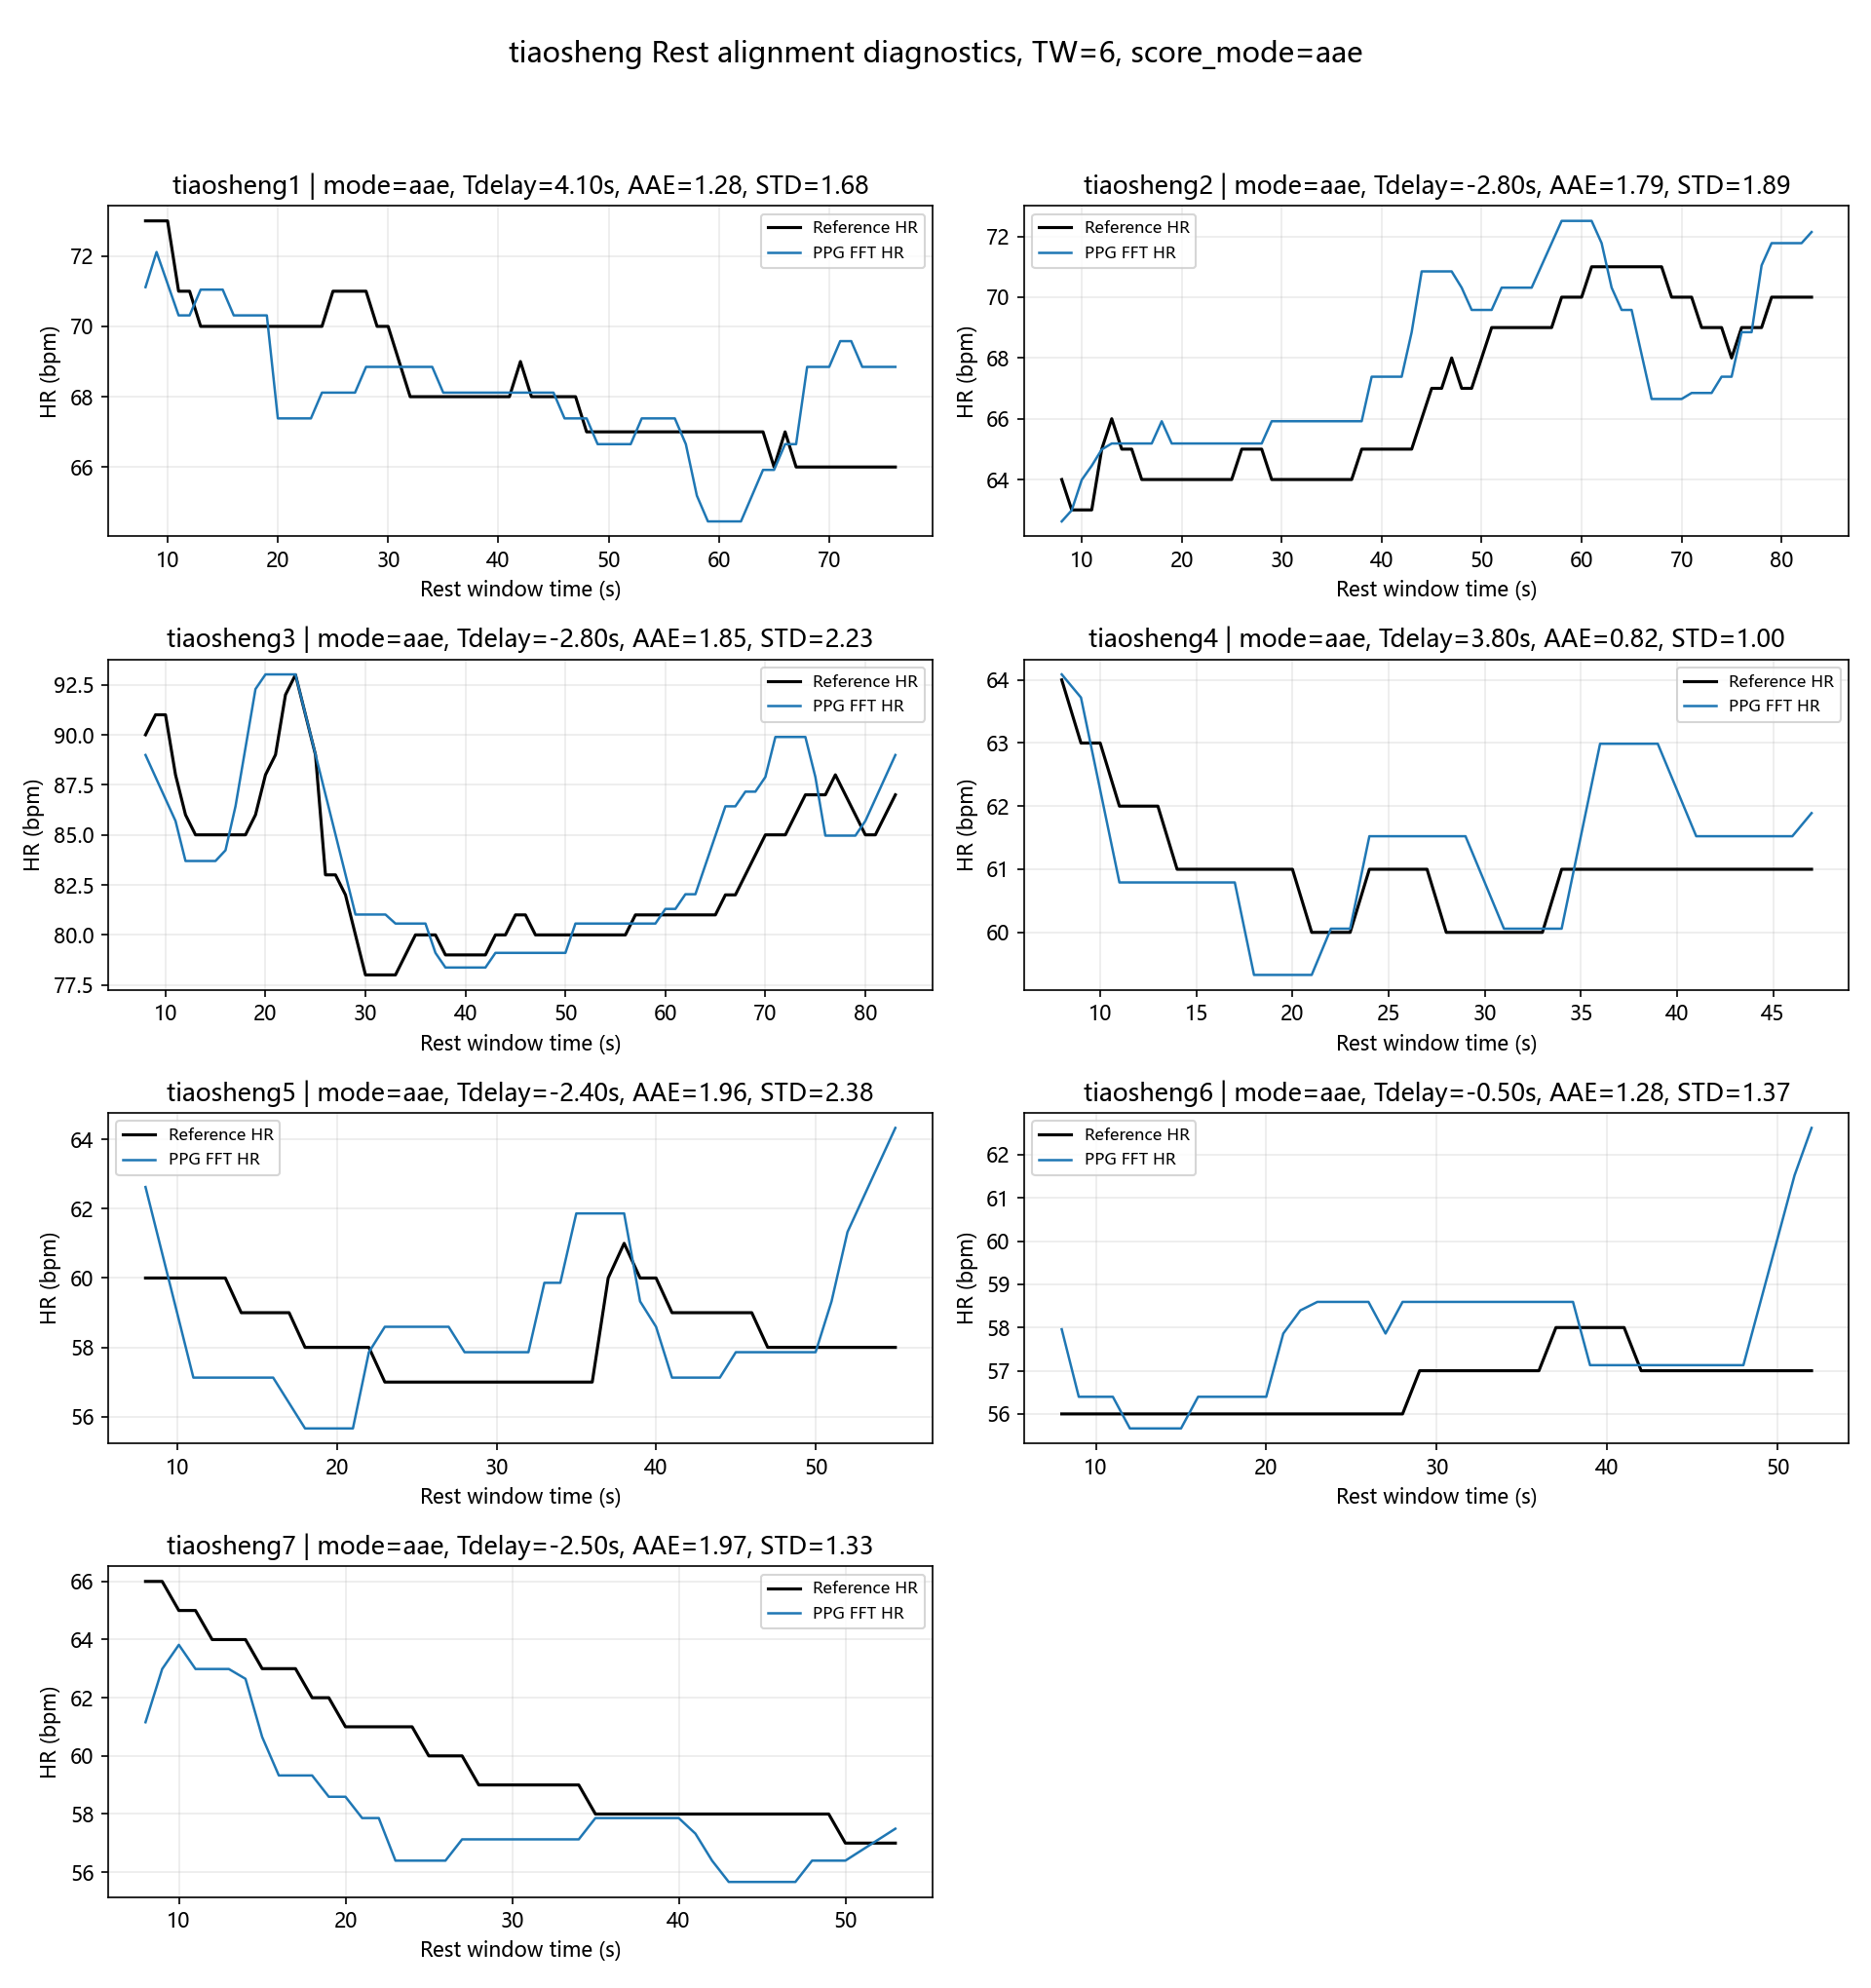

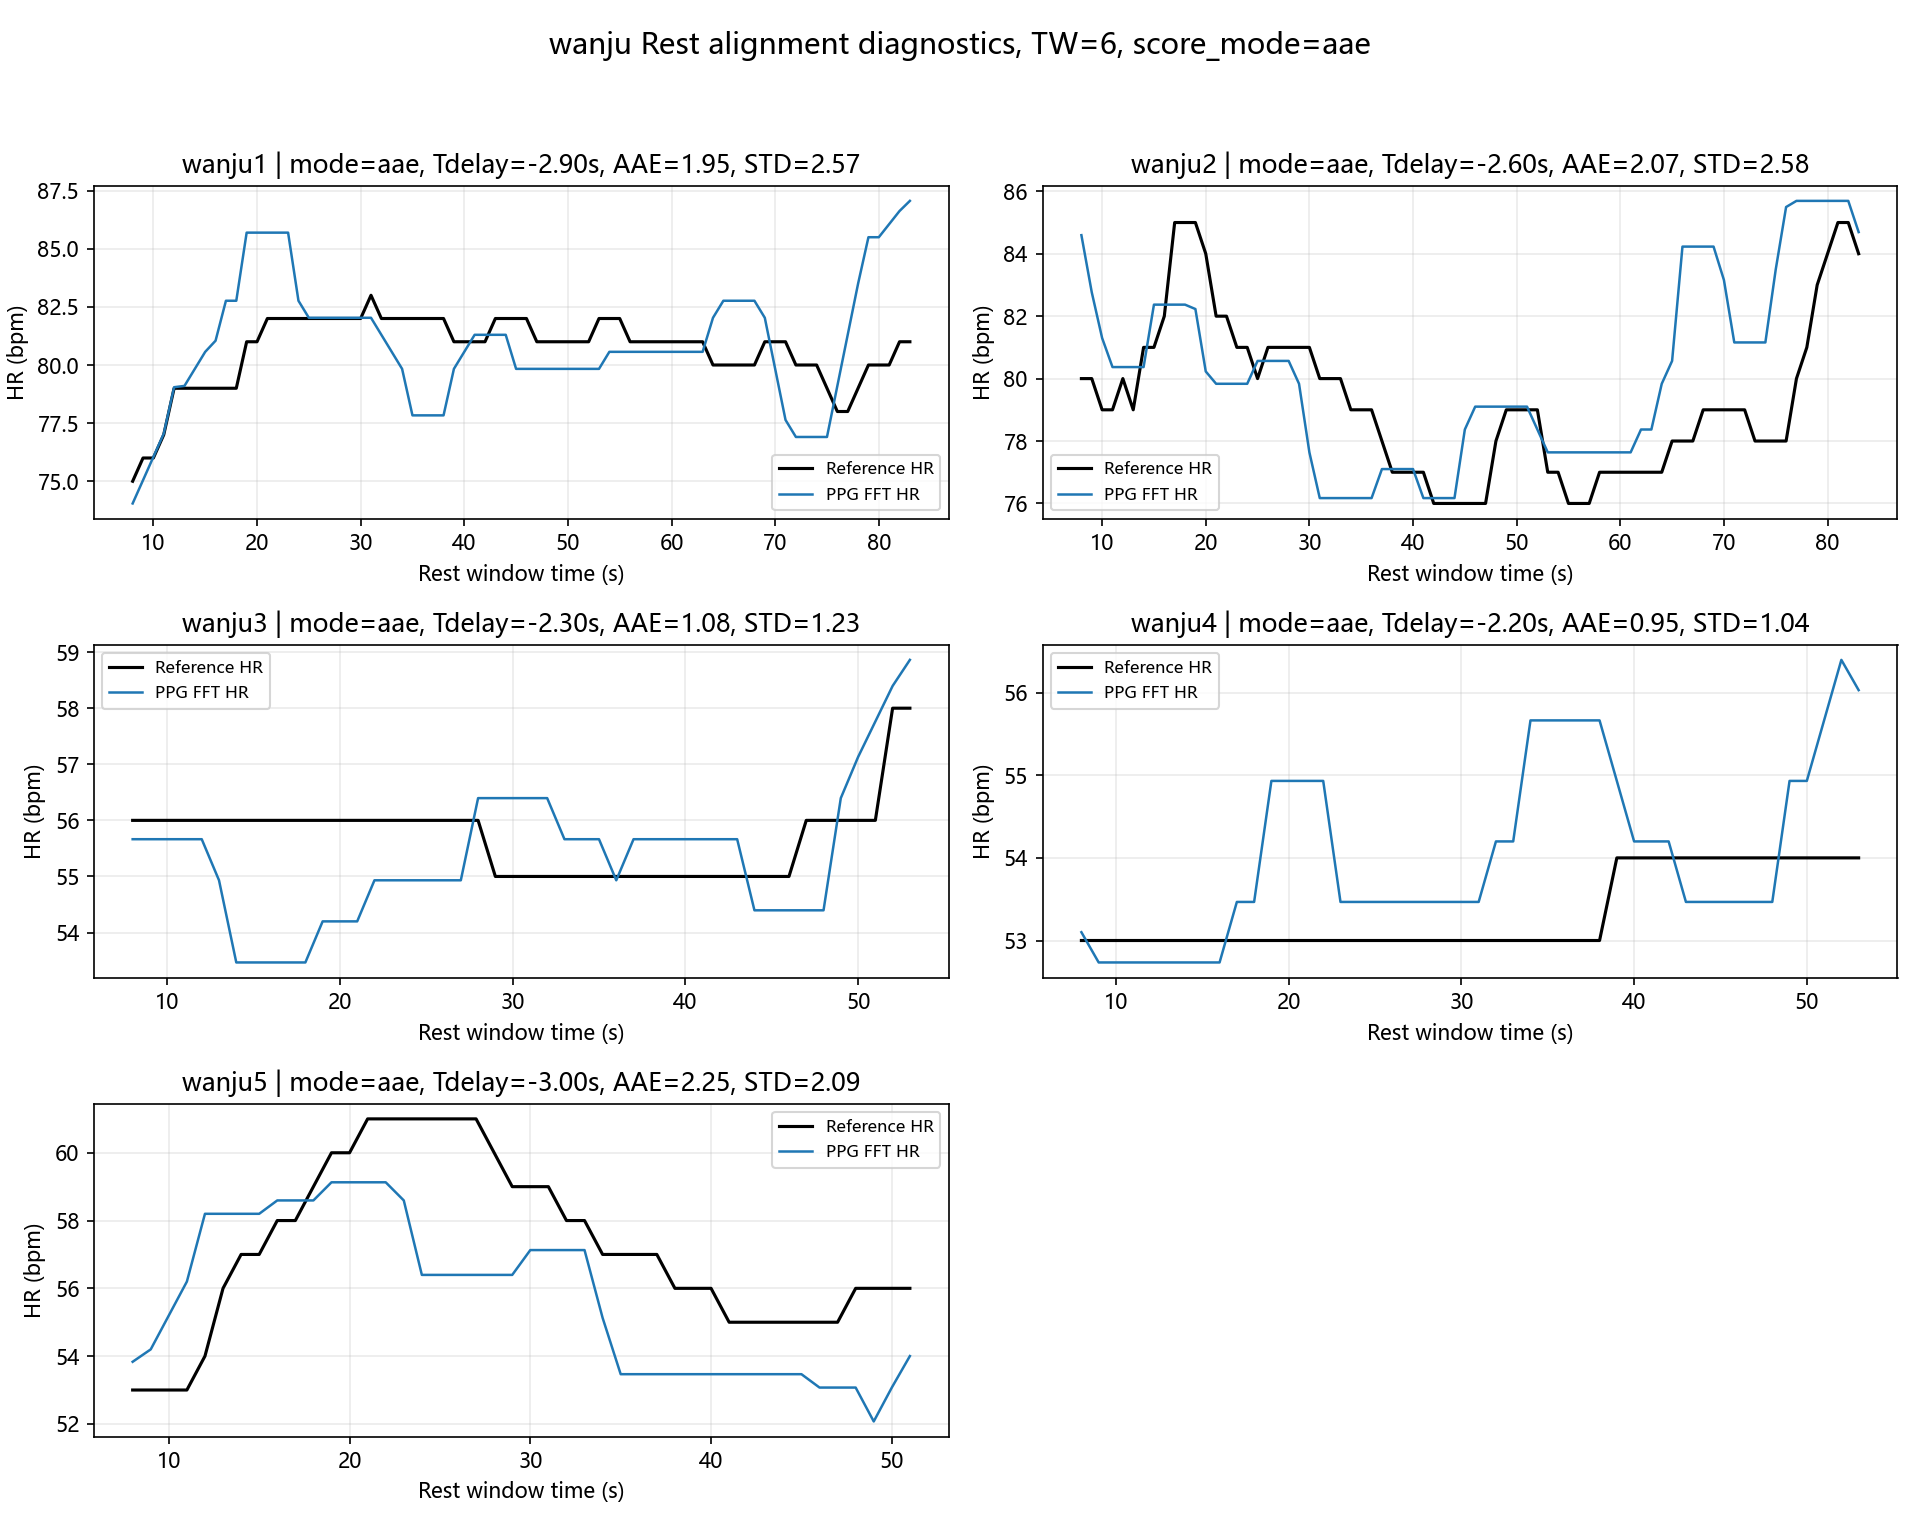

In [4]:
ALIGNMENT_DIAGNOSTIC_DIR = RUN_OUTPUT_DIR / "alignment_diagnostics"

# 为诊断图加载原始数据集。这里保存到字典，后续第 4、6 部分会复用，减少重复读取 CSV。
alignment_diagnostic_datasets = {}
for pair in good_pairs:
    try:
        alignment_diagnostic_datasets[pair.motion_id] = load_and_preprocess_protocol(
            pair.sensor_csv,
            pair.ref_csv,
            fs_origin=FS_ORIGIN,
        )
    except Exception as exc:
        print(f"alignment diagnostic preprocessing failed: {pair.motion_id}: {exc}")

# TW 参数用于文件名和图标题显示；真正的静息 HR 提取参数通过 alignment_TW 和 REST_HR_KWARGS 传入。
alignment_diagnostic_paths = plot_rest_alignment_diagnostics_by_motion_type(
    pairs=good_pairs,
    datasets=alignment_diagnostic_datasets,
    output_dir=ALIGNMENT_DIAGNOSTIC_DIR,
    fs_target=100,
    TW=int(ALIGNMENT_TW),
    alignment_TW=ALIGNMENT_TW,
    alignment_step_s=ALIGNMENT_STEP_S,
    rest_hr_kwargs=REST_HR_KWARGS,
    alignment_score_mode=REST_ALIGNMENT_SCORE_MODE,
)
print("alignment_diagnostics:", alignment_diagnostic_paths)
for image_path in alignment_diagnostic_paths.values():
    display(Image(filename=str(image_path)))


## 4. 全段未对齐 PPG-HR 测试图

本部分不做全局 Tdelay 对齐，直接对完整 PPG_Green 信号按 `FULLFIELD_PPG_HR_TW` 分窗，使用 Hamming + FFT、上一 HR 邻域追踪、slew limit/step 和 moving median 平滑得到 PPG-HR。

图中会同时标出静息、运动和运动恢复区域，方便判断异常是否来自原始 PPG 主频、分段位置或后处理参数。


fullfield_ppg_hr_paths: {'bobi': WindowsPath('D:/python_notebook_base/outputs/allfield/bobi_all_alignment_TW6.png'), 'fuwo': WindowsPath('D:/python_notebook_base/outputs/allfield/fuwo_all_alignment_TW6.png'), 'kaihe': WindowsPath('D:/python_notebook_base/outputs/allfield/kaihe_all_alignment_TW6.png'), 'tiaosheng': WindowsPath('D:/python_notebook_base/outputs/allfield/tiaosheng_all_alignment_TW6.png'), 'wanju': WindowsPath('D:/python_notebook_base/outputs/allfield/wanju_all_alignment_TW6.png')}


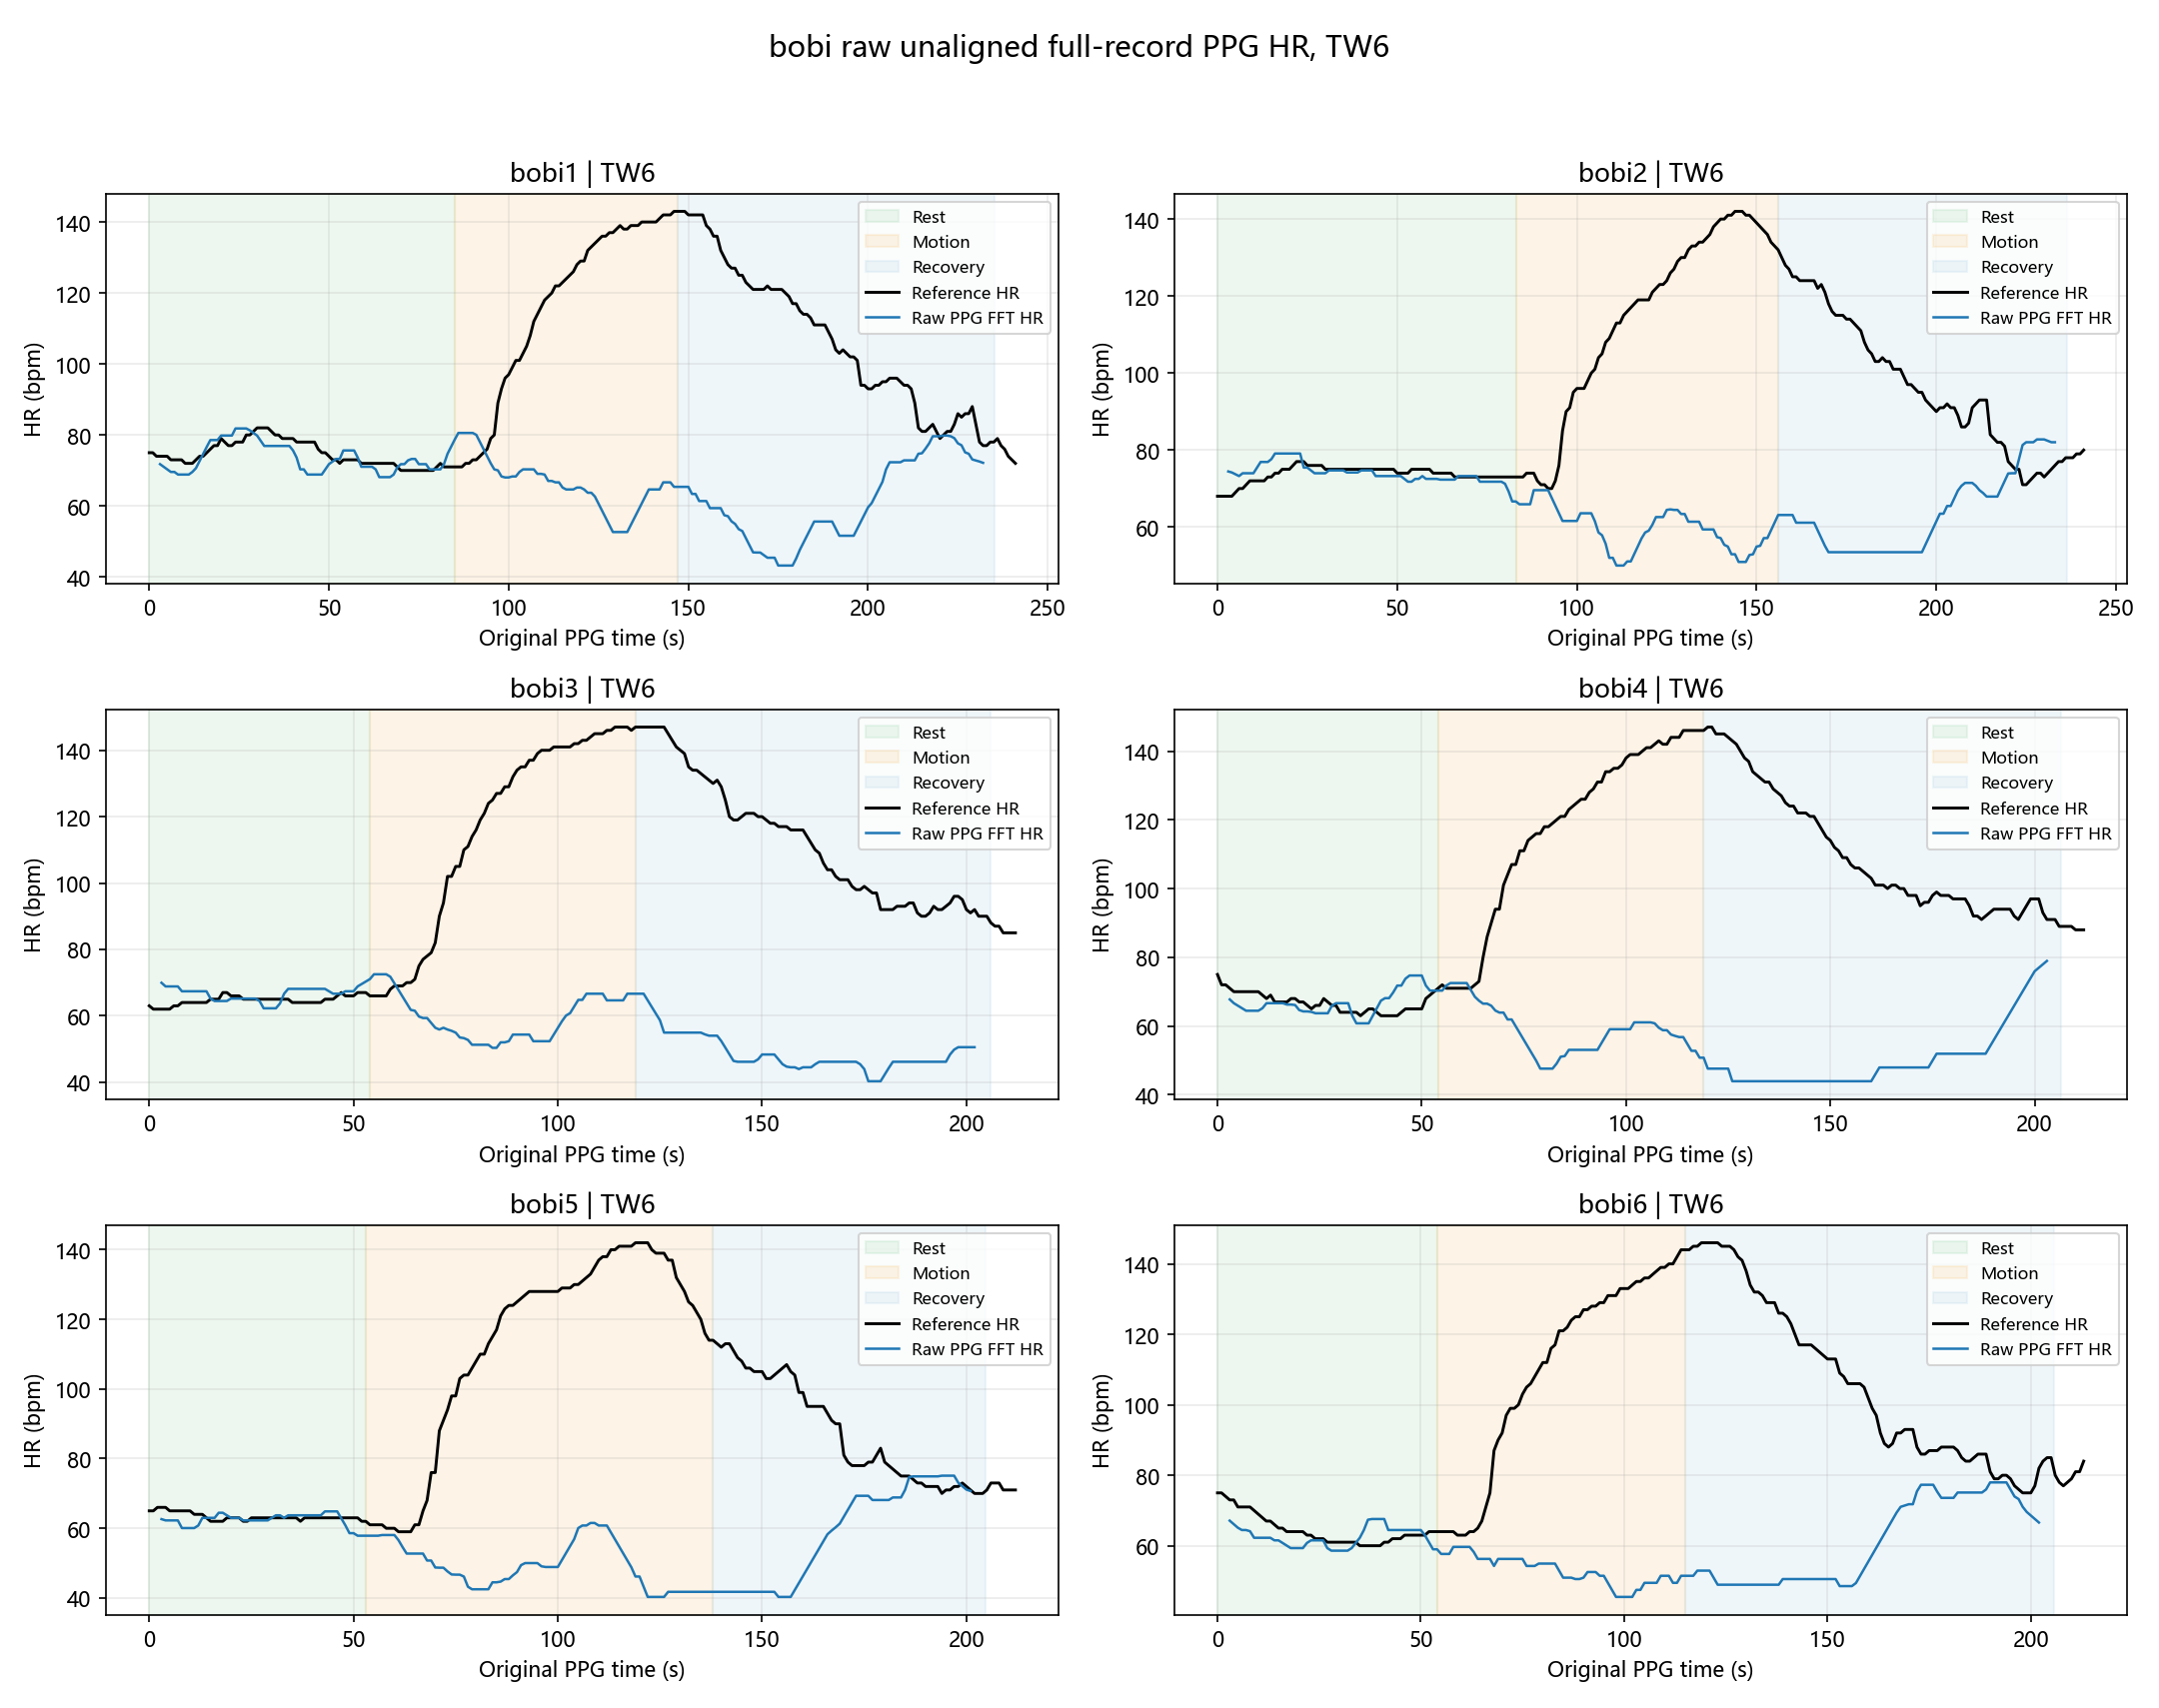

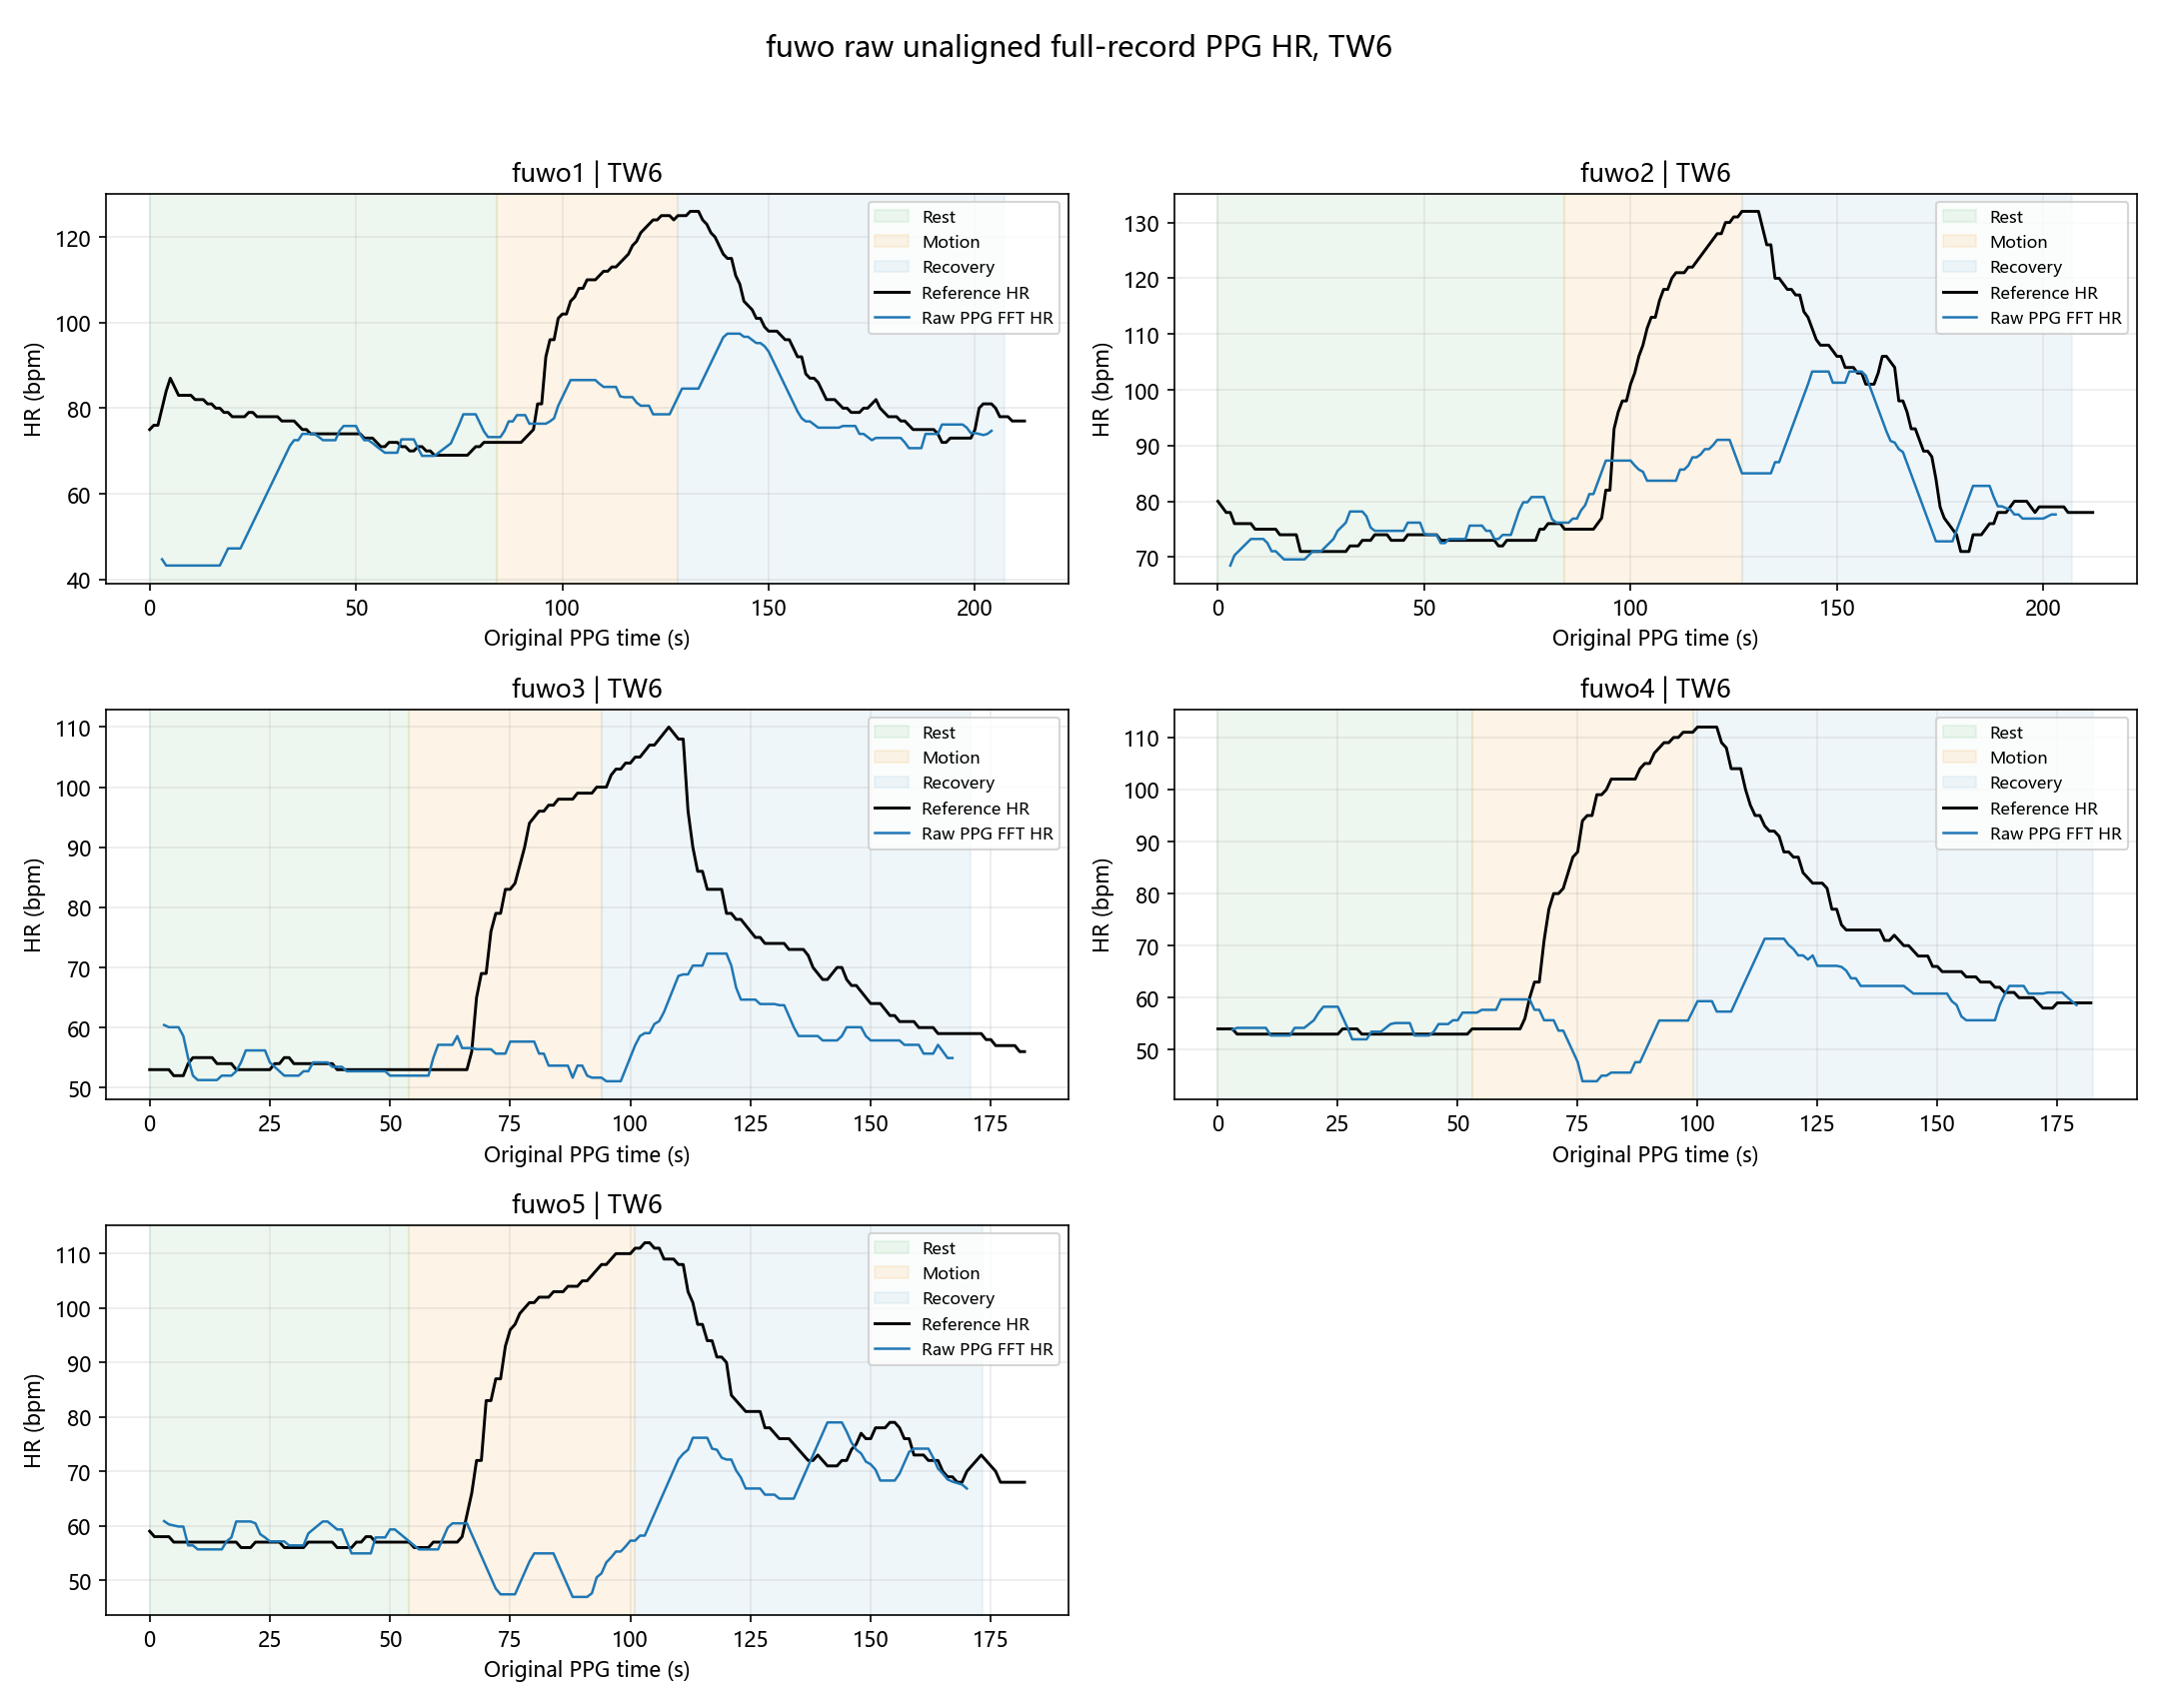

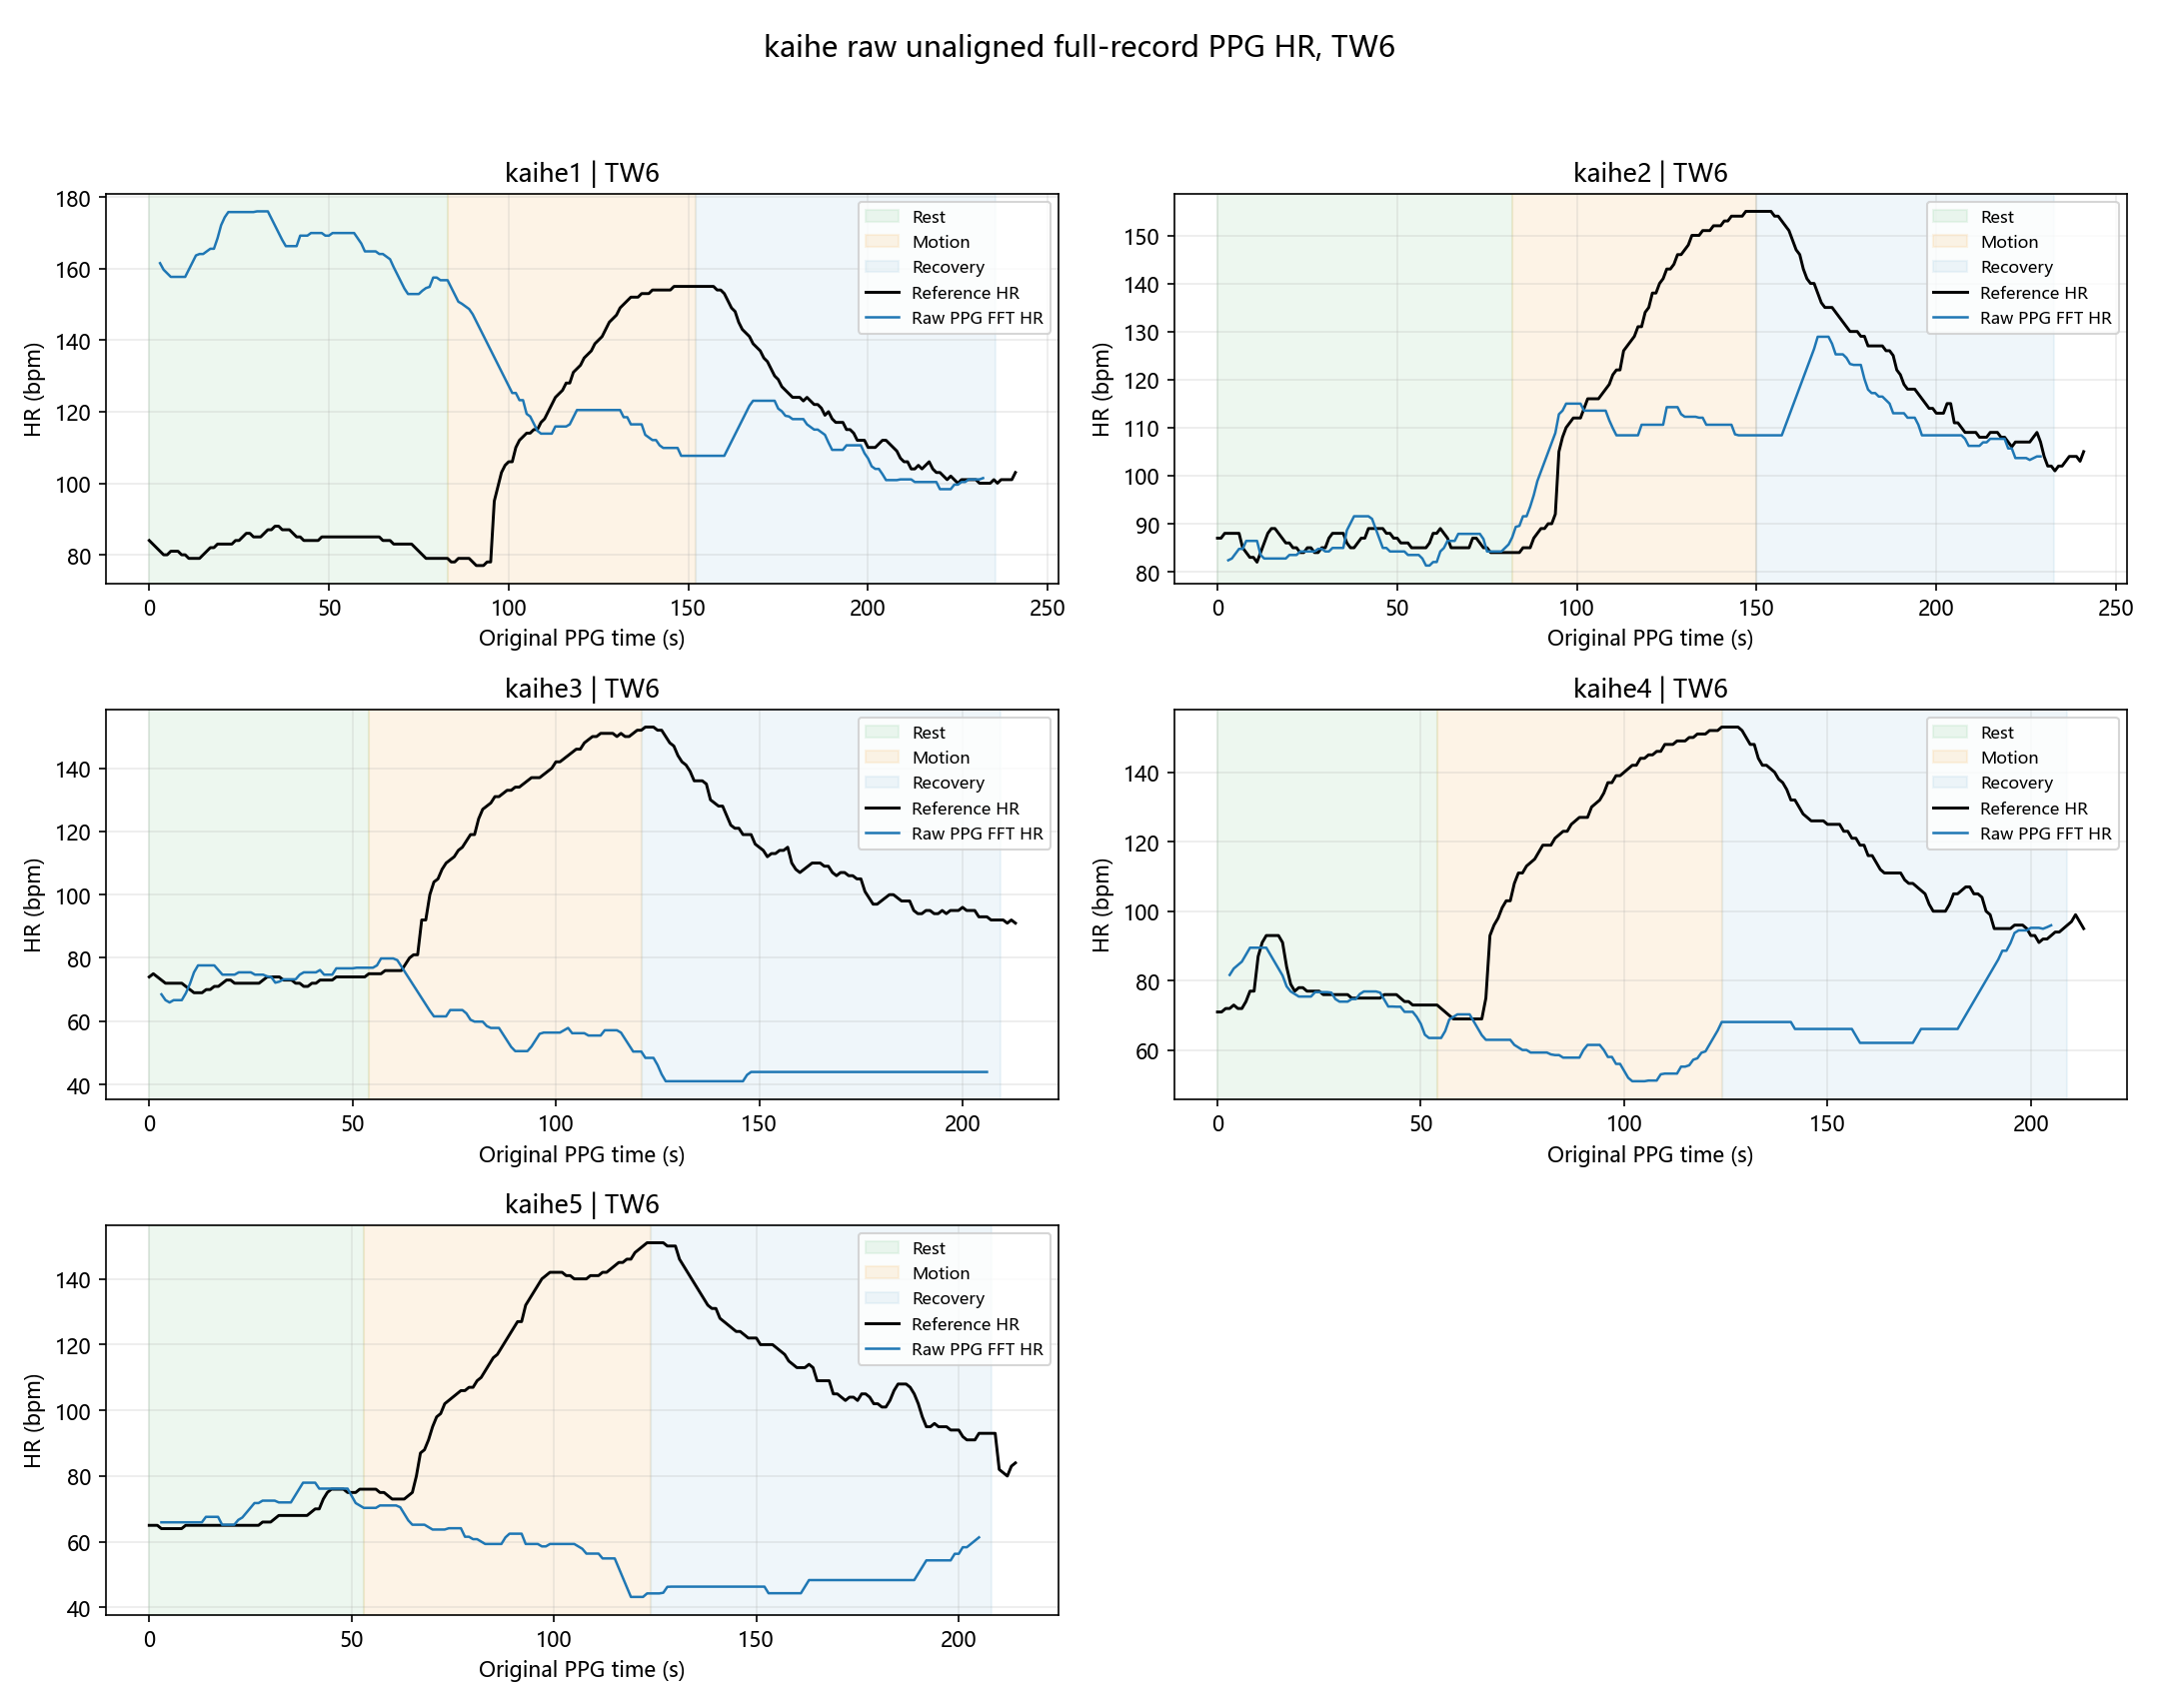

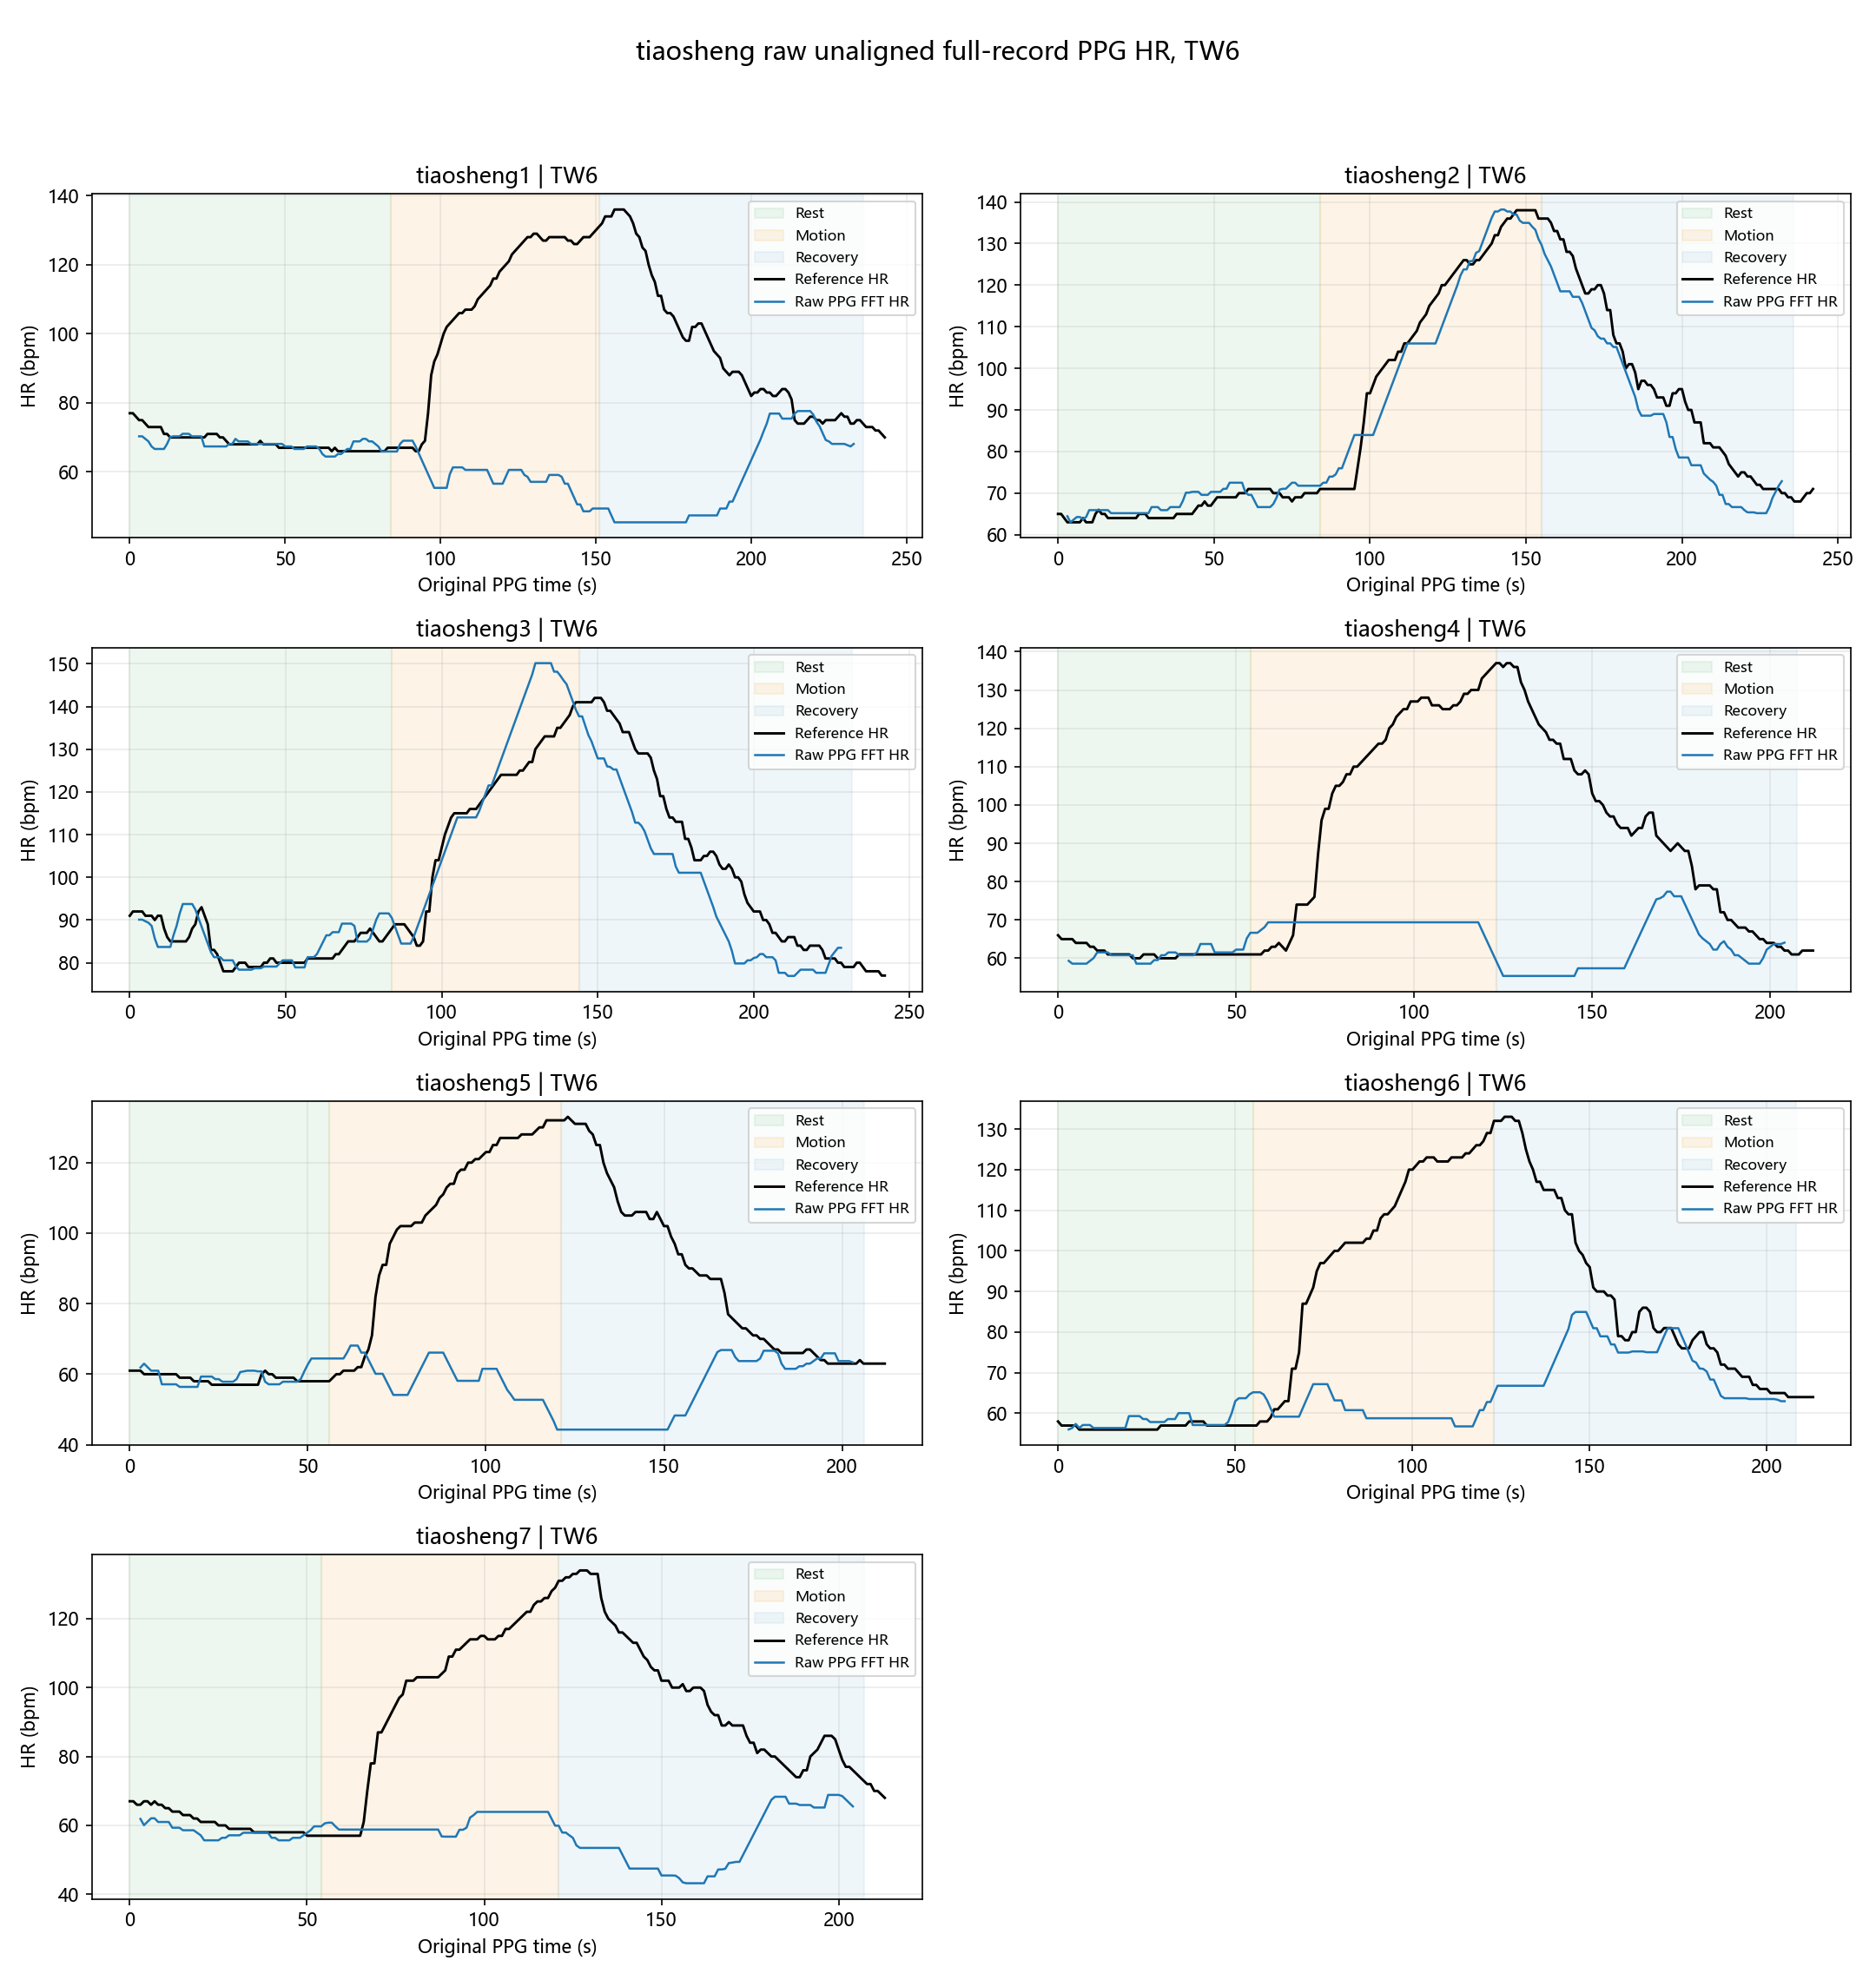

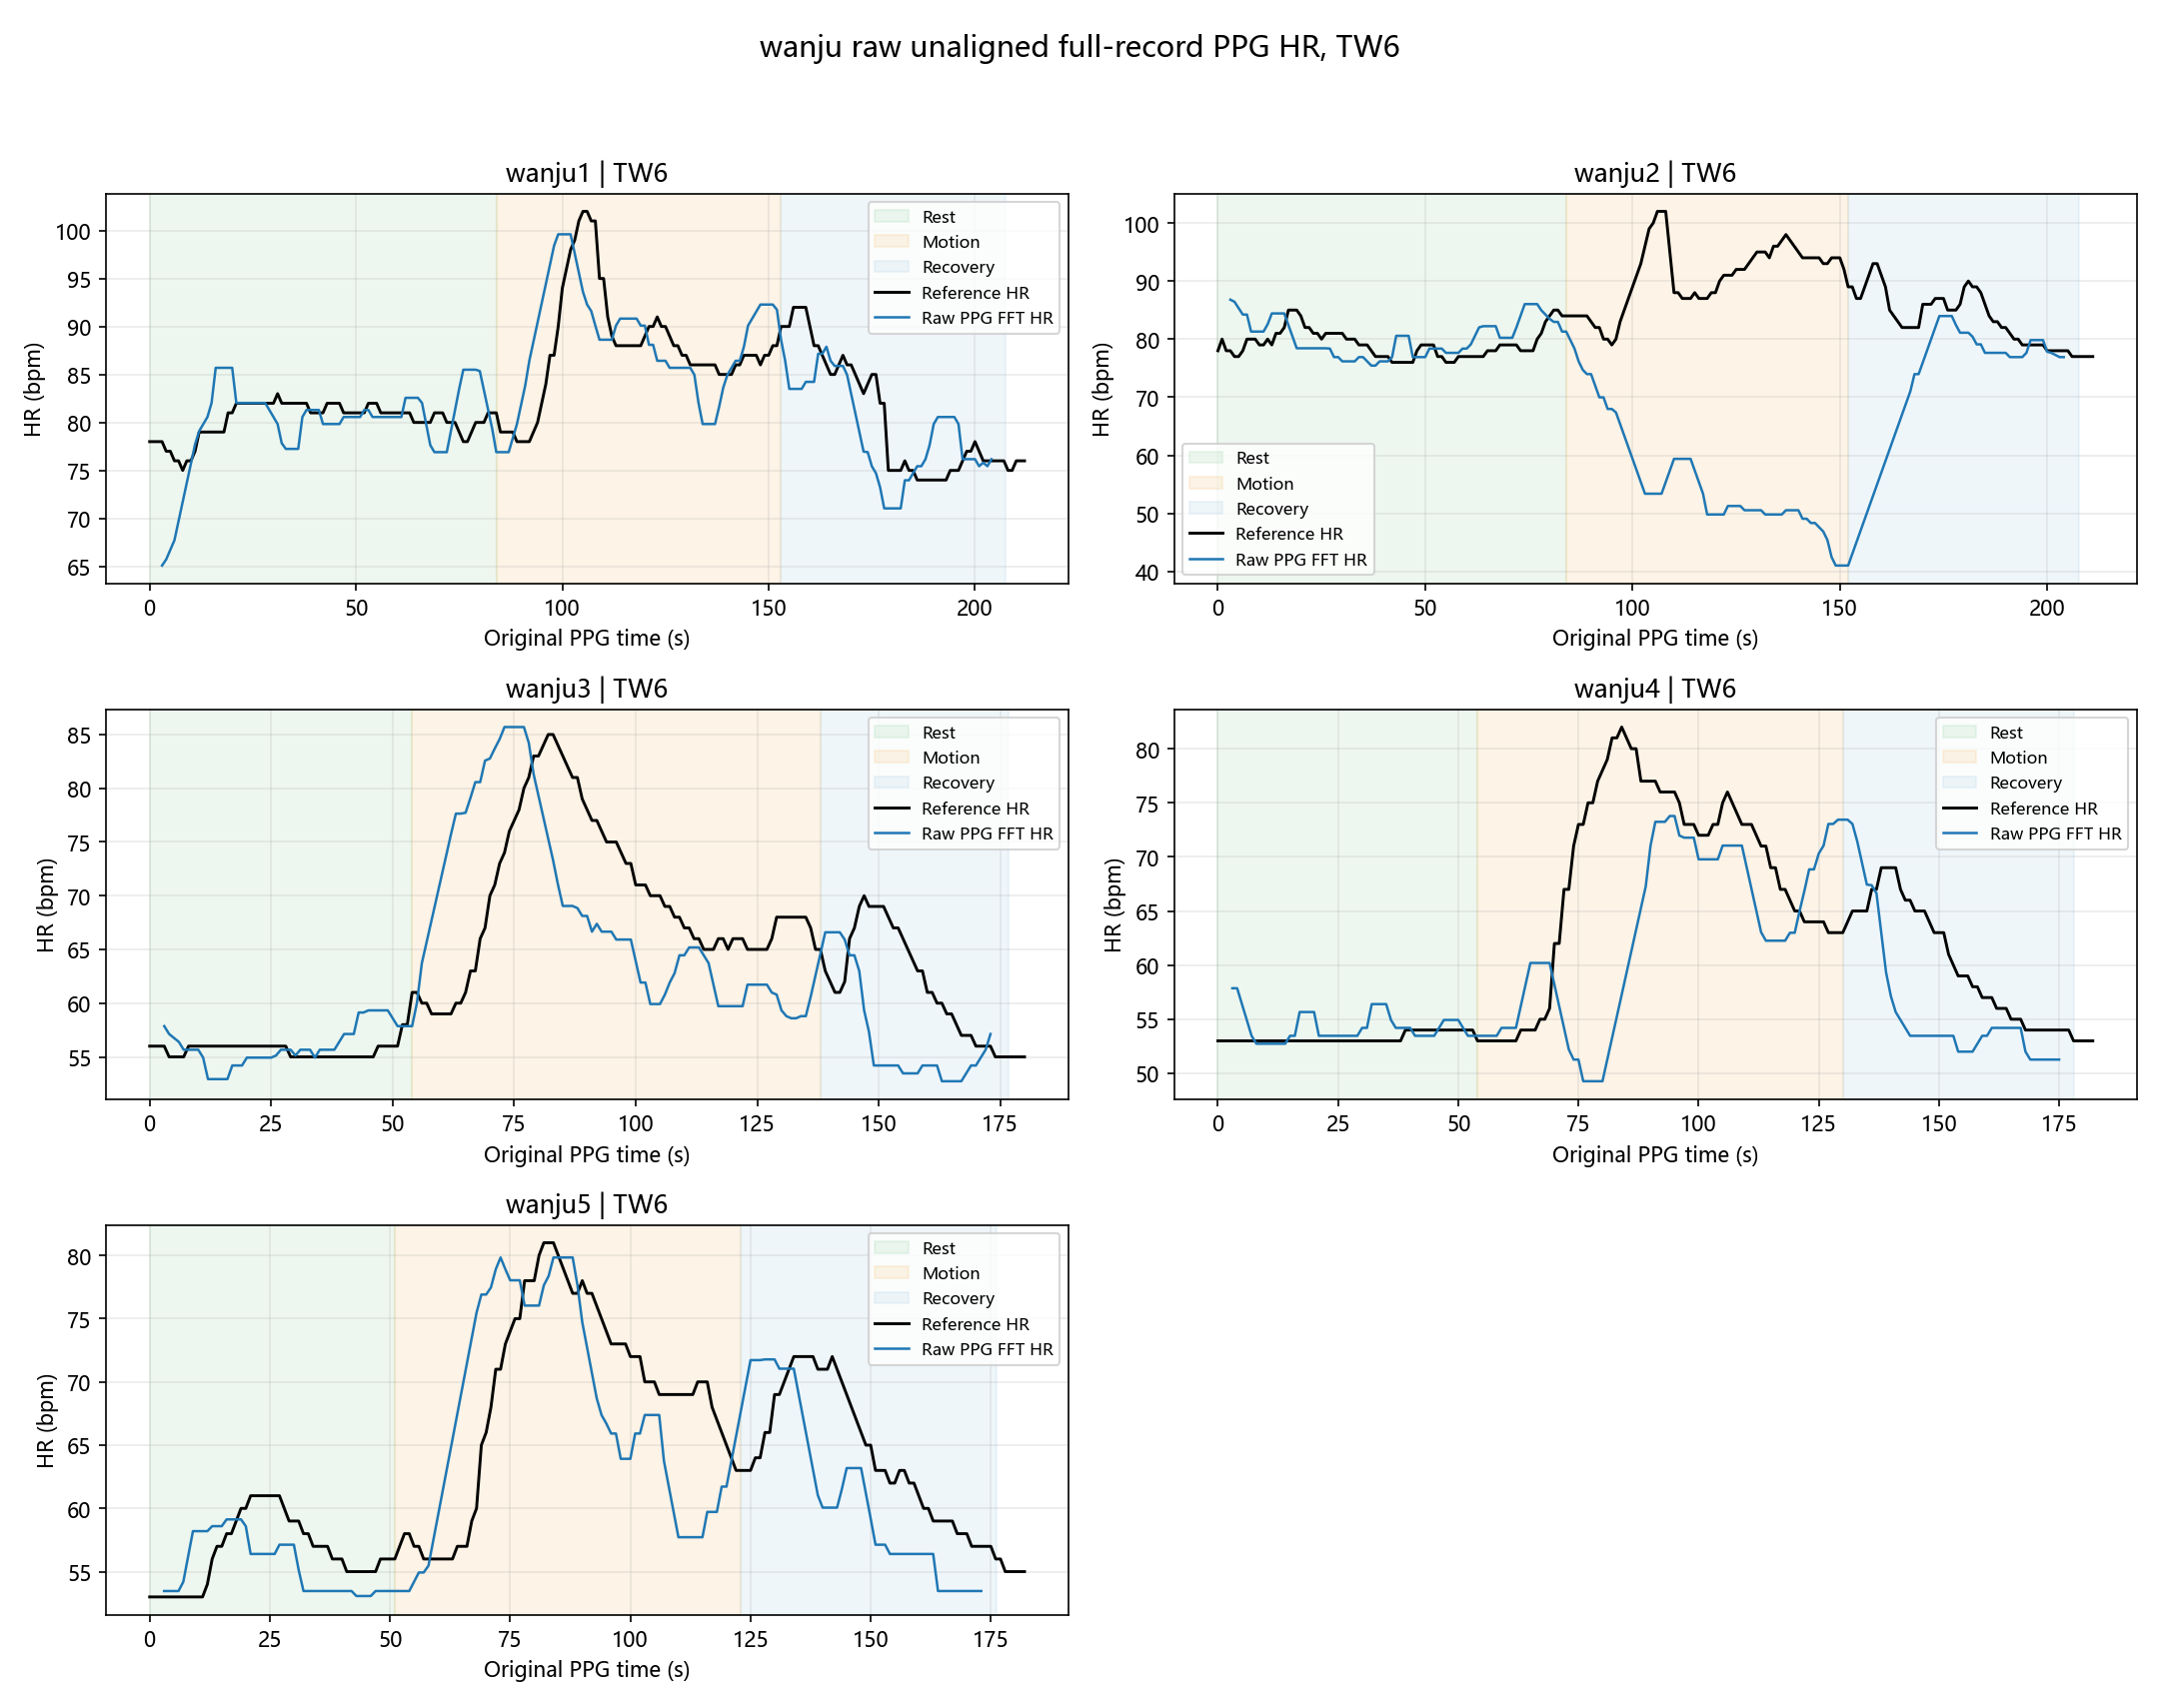

In [5]:
FULLFIELD_PPG_HR_DIR = OUTPUT_ROOT / "allfield"
FULLFIELD_PPG_HR_TW = int(ALIGNMENT_TW)

# 复用第 3 部分已加载的数据；如果某个样本缺失，则在这里补加载。
fullfield_ppg_hr_datasets = dict(globals().get("alignment_diagnostic_datasets", {}))
for pair in good_pairs:
    if pair.motion_id in fullfield_ppg_hr_datasets:
        continue
    try:
        fullfield_ppg_hr_datasets[pair.motion_id] = load_and_preprocess_protocol(
            pair.sensor_csv,
            pair.ref_csv,
            fs_origin=FS_ORIGIN,
        )
    except Exception as exc:
        print(f"fullfield PPG-HR preprocessing failed: {pair.motion_id}: {exc}")

# 每个 motion_type 输出一张图；文件位于 outputs/allfield，命名包含运动类型和时间窗长度。
fullfield_ppg_hr_paths = plot_unaligned_fullfield_ppg_hr_by_motion_type(
    pairs=good_pairs,
    datasets=fullfield_ppg_hr_datasets,
    output_dir=FULLFIELD_PPG_HR_DIR,
    fs_target=100,
    TW=FULLFIELD_PPG_HR_TW,
    hr_band_hz=REST_HR_BAND_HZ,
    track_band_bpm=REST_HR_TRACK_BAND_BPM,
    slew_limit_bpm=REST_HR_SLEW_LIMIT_BPM,
    slew_step_bpm=REST_HR_SLEW_STEP_BPM,
    smooth_method=REST_HR_SMOOTH_METHOD,
    smooth_win=REST_HR_SMOOTH_WIN,
    peak_percent=REST_HR_PEAK_PERCENT,
    spec_penalty_enable=REST_HR_SPEC_PENALTY_ENABLE,
    spec_penalty_weight=REST_HR_SPEC_PENALTY_WEIGHT,
    spec_penalty_width_hz=REST_HR_SPEC_PENALTY_WIDTH_HZ,
)
print("fullfield_ppg_hr_paths:", fullfield_ppg_hr_paths)
for image_path in fullfield_ppg_hr_paths.values():
    display(Image(filename=str(image_path)))


## 5. 训练辅助函数

本部分封装训练单元会反复用到的函数：

- `make_budgets`：快速生成每个 cascade scheme 的 Optuna trial/repeat 数。
- `notebook_progress`：控制 notebook 里的训练进度输出频率。
- `run_training_cell`：统一调用 `run_batch_adaptive_protocol`，减少后续训练单元重复代码。

注意：`run_training_cell` 默认把第 0 单元的 `REST_HR_TRIAL_OVERRIDES` 传入训练流程，因此静息 HR 和 Tdelay 参数可以集中调整。


In [6]:
def make_budgets(schemes, n_trials=1, n_repeats=1):
    '''为每个 cascade scheme 生成相同的 Optuna 搜索预算。'''
    return {scheme: {"n_trials": int(n_trials), "n_repeats": int(n_repeats)} for scheme in schemes}

PROGRESS_EVERY_N_TRIALS = 10

def notebook_progress(info):
    '''Notebook 进度回调：只打印关键 trial，避免长时间训练刷屏。'''
    stage = info.get("stage", "")
    if stage == "optimization":
        trial_idx = int(info.get("trial_idx") or 0)
        trial_total = int(info.get("trial_total") or 0)
        if trial_idx == 1 or trial_idx == trial_total or trial_idx % PROGRESS_EVERY_N_TRIALS == 0:
            print(
                f"motion_type {info.get('motion_type')} | "
                f"mode {info.get('mode_idx')}/{info.get('mode_total')} | "
                f"{info.get('target_scope_value')} / {info.get('cascade_scheme')} / {info.get('adaptive_filter')} | "
                f"repeat {info.get('repeat_idx')}/{info.get('repeat_total')} | "
                f"trial {trial_idx}/{trial_total} | "
                f"AAE {info.get('aae_bpm')} | accuracy {info.get('accuracy_pct')} | "
                f"objective_mode {info.get('objective_mode')} | objective_value {info.get('objective_value')}"
            )
    elif stage == "optimization_mode":
        print(
            f"enter mode {info.get('mode_idx')}/{info.get('mode_total')}: "
            f"{info.get('motion_type')} / {info.get('target_scope_value')} / "
            f"{info.get('cascade_scheme')} / {info.get('adaptive_filter')}"
        )
    elif stage == "optimization_parallel_repeats_start":
        print(
            f"parallel repeats start: n_jobs={info.get('n_jobs')}, repeats={info.get('repeat_total')} | "
            f"{info.get('motion_type')} / {info.get('target_scope_value')} / "
            f"{info.get('cascade_scheme')} / {info.get('adaptive_filter')} / fold={info.get('fold_id')}"
        )
    elif stage == "optimization_parallel_repeat_done":
        print(
            f"repeat {info.get('repeat_current')}/{info.get('repeat_total')} done "
            f"({info.get('repeat_done')}/{info.get('repeat_total')} completed), "
            f"best={info.get('best_value'):.4f}, global_best={info.get('global_best_value'):.4f}"
        )
    elif stage in {"qc", "preprocess"}:
        print(f"{stage} {info.get('current')}/{info.get('total')}: {info.get('sample')}")

def run_training_cell(
    *,
    active_target_scopes,
    active_cascade_schemes,
    active_adaptive_filters,
    cascade_train_budgets,
    optimization_objective,
    data_split_mode,
    val_groups_per_type=1,
    test_groups_per_type=1,
    delay_estimation_mode=DELAY_ESTIMATION_MODE,
    trial_param_overrides=REST_HR_TRIAL_OVERRIDES,
):
    '''运行一次批处理训练。

    输入数据来自 TESTDATA_DIR 中的传感器 CSV 与 ref CSV。
    函数内部会完成 QC、预处理、分段、Optuna 搜索、best_params 复评估和 CSV/PNG 输出。
    trial_param_overrides 用于传入非 Optuna 参数，尤其是静息 HR 提取与全局 Tdelay 估计参数。
    '''
    output_run_name, run_output_dir = make_unique_output_dir(
        active_target_scopes,
        active_cascade_schemes,
        active_adaptive_filters,
        optimization_objective,
        data_split_mode,
    )
    print("OUTPUT_RUN_NAME:", output_run_name)
    print("RUN_OUTPUT_DIR:", run_output_dir)
    print("trial_param_overrides:", trial_param_overrides)
    result = run_batch_adaptive_protocol(
        input_dir=TESTDATA_DIR,
        output_root=run_output_dir,
        max_iterations=1,
        num_repeats=1,
        random_state=RANDOM_STATE,
        num_seed_points=1,
        fs_origin=FS_ORIGIN,
        n_jobs=3,
        debug_mode=True,
        search_space=ProtocolSearchParams(),
        trial_param_overrides=trial_param_overrides,
        target_scopes=active_target_scopes,
        cascade_schemes=active_cascade_schemes,
        adaptive_filters=active_adaptive_filters,
        objective_mode=optimization_objective,
        data_split_mode=data_split_mode,
        delay_estimation_mode=delay_estimation_mode,
        val_groups_per_type=val_groups_per_type,
        test_groups_per_type=test_groups_per_type,
        cascade_train_budgets=cascade_train_budgets,
        project_root=PROJECT_ROOT,
        clean_outputs=CLEAN_OUTPUTS,
        verbose=True,
        on_log=print,
        progress_callback=notebook_progress,
    )
    print("batch_summary:", result.batch_summary_csv)
    print("final_summary:", result.final_summary_tables)
    return result


## 6. 静息段原始 PPG 与 PPG-HR 双 y 轴图

本部分每个运动类型输出一张图，每个子图对应一组运动：

- 左轴：静息段 PPG_Green 原始波形。
- 右轴：静息段 PPG 解算心率曲线。

它用于排查静息段心率偏差来源：如果原始 PPG 波形质量差、强漂移或周期不稳定，单纯调整 FFT 后处理可能无法解决。


raw_ppg_dual_axis_paths: {'bobi': WindowsPath('D:/python_notebook_base/outputs/allfield/bobi_rest_raw_ppg_hr_dual_axis_TW6.png'), 'fuwo': WindowsPath('D:/python_notebook_base/outputs/allfield/fuwo_rest_raw_ppg_hr_dual_axis_TW6.png'), 'kaihe': WindowsPath('D:/python_notebook_base/outputs/allfield/kaihe_rest_raw_ppg_hr_dual_axis_TW6.png'), 'tiaosheng': WindowsPath('D:/python_notebook_base/outputs/allfield/tiaosheng_rest_raw_ppg_hr_dual_axis_TW6.png'), 'wanju': WindowsPath('D:/python_notebook_base/outputs/allfield/wanju_rest_raw_ppg_hr_dual_axis_TW6.png')}


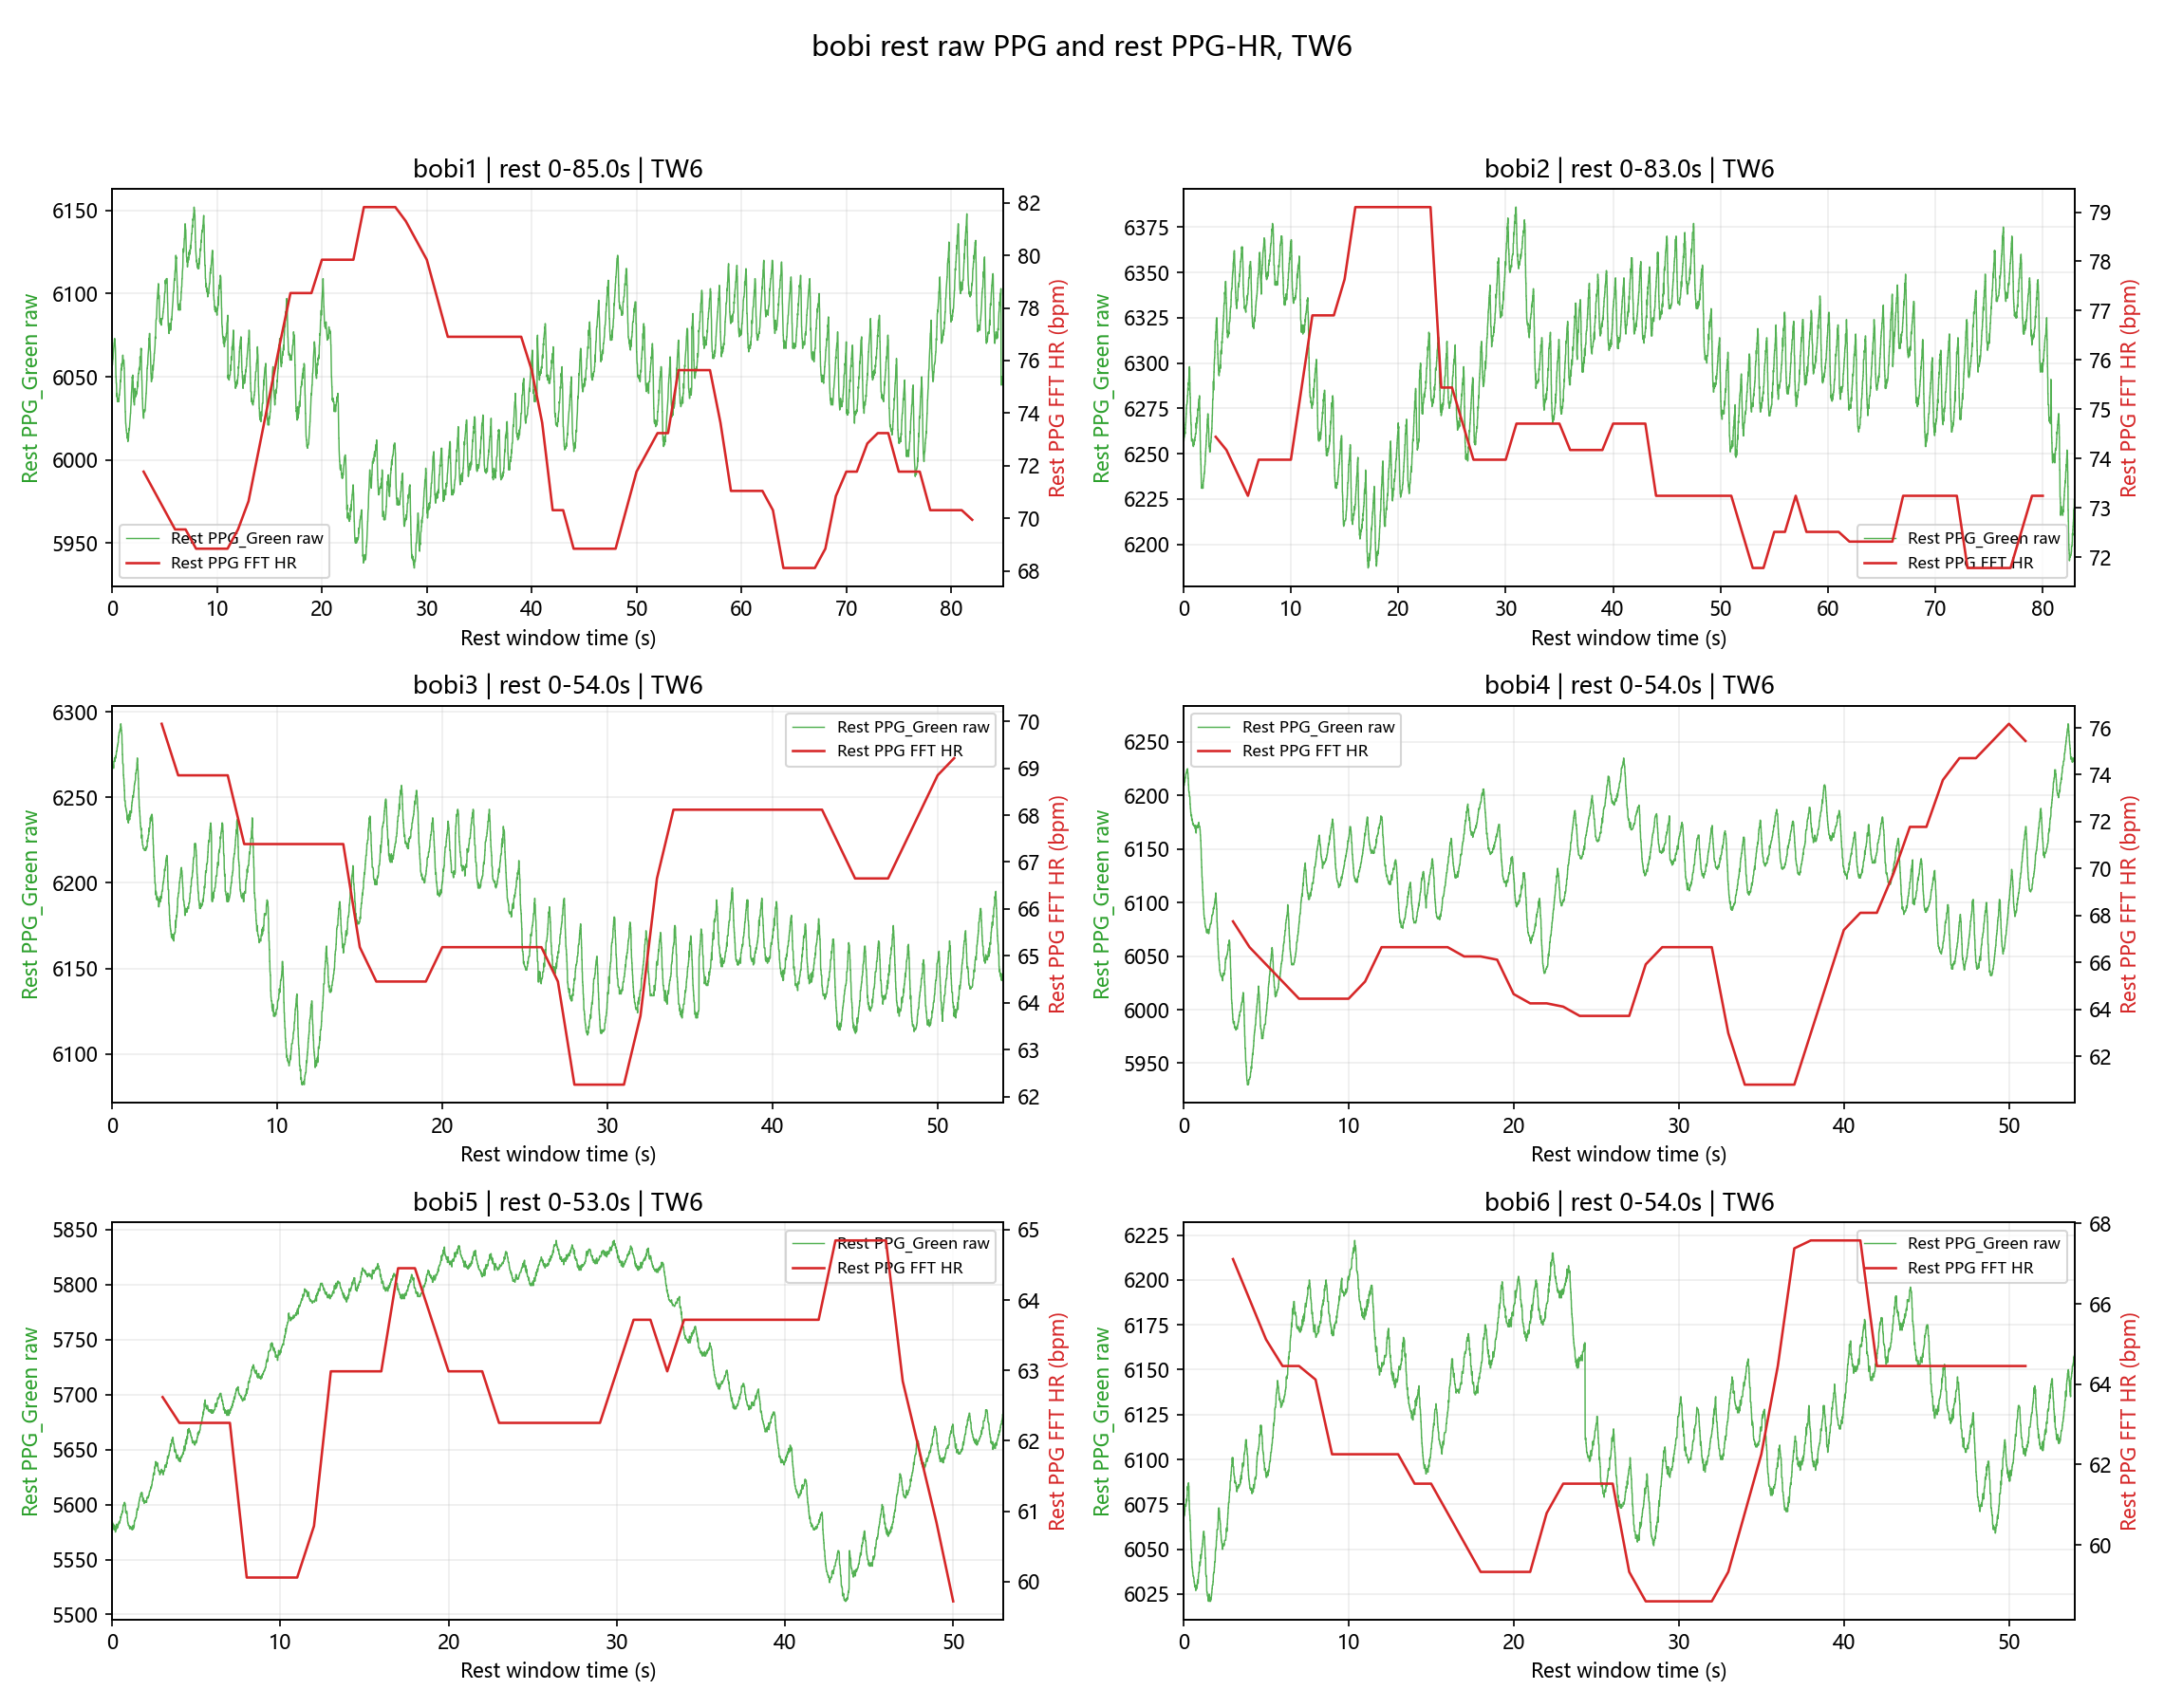

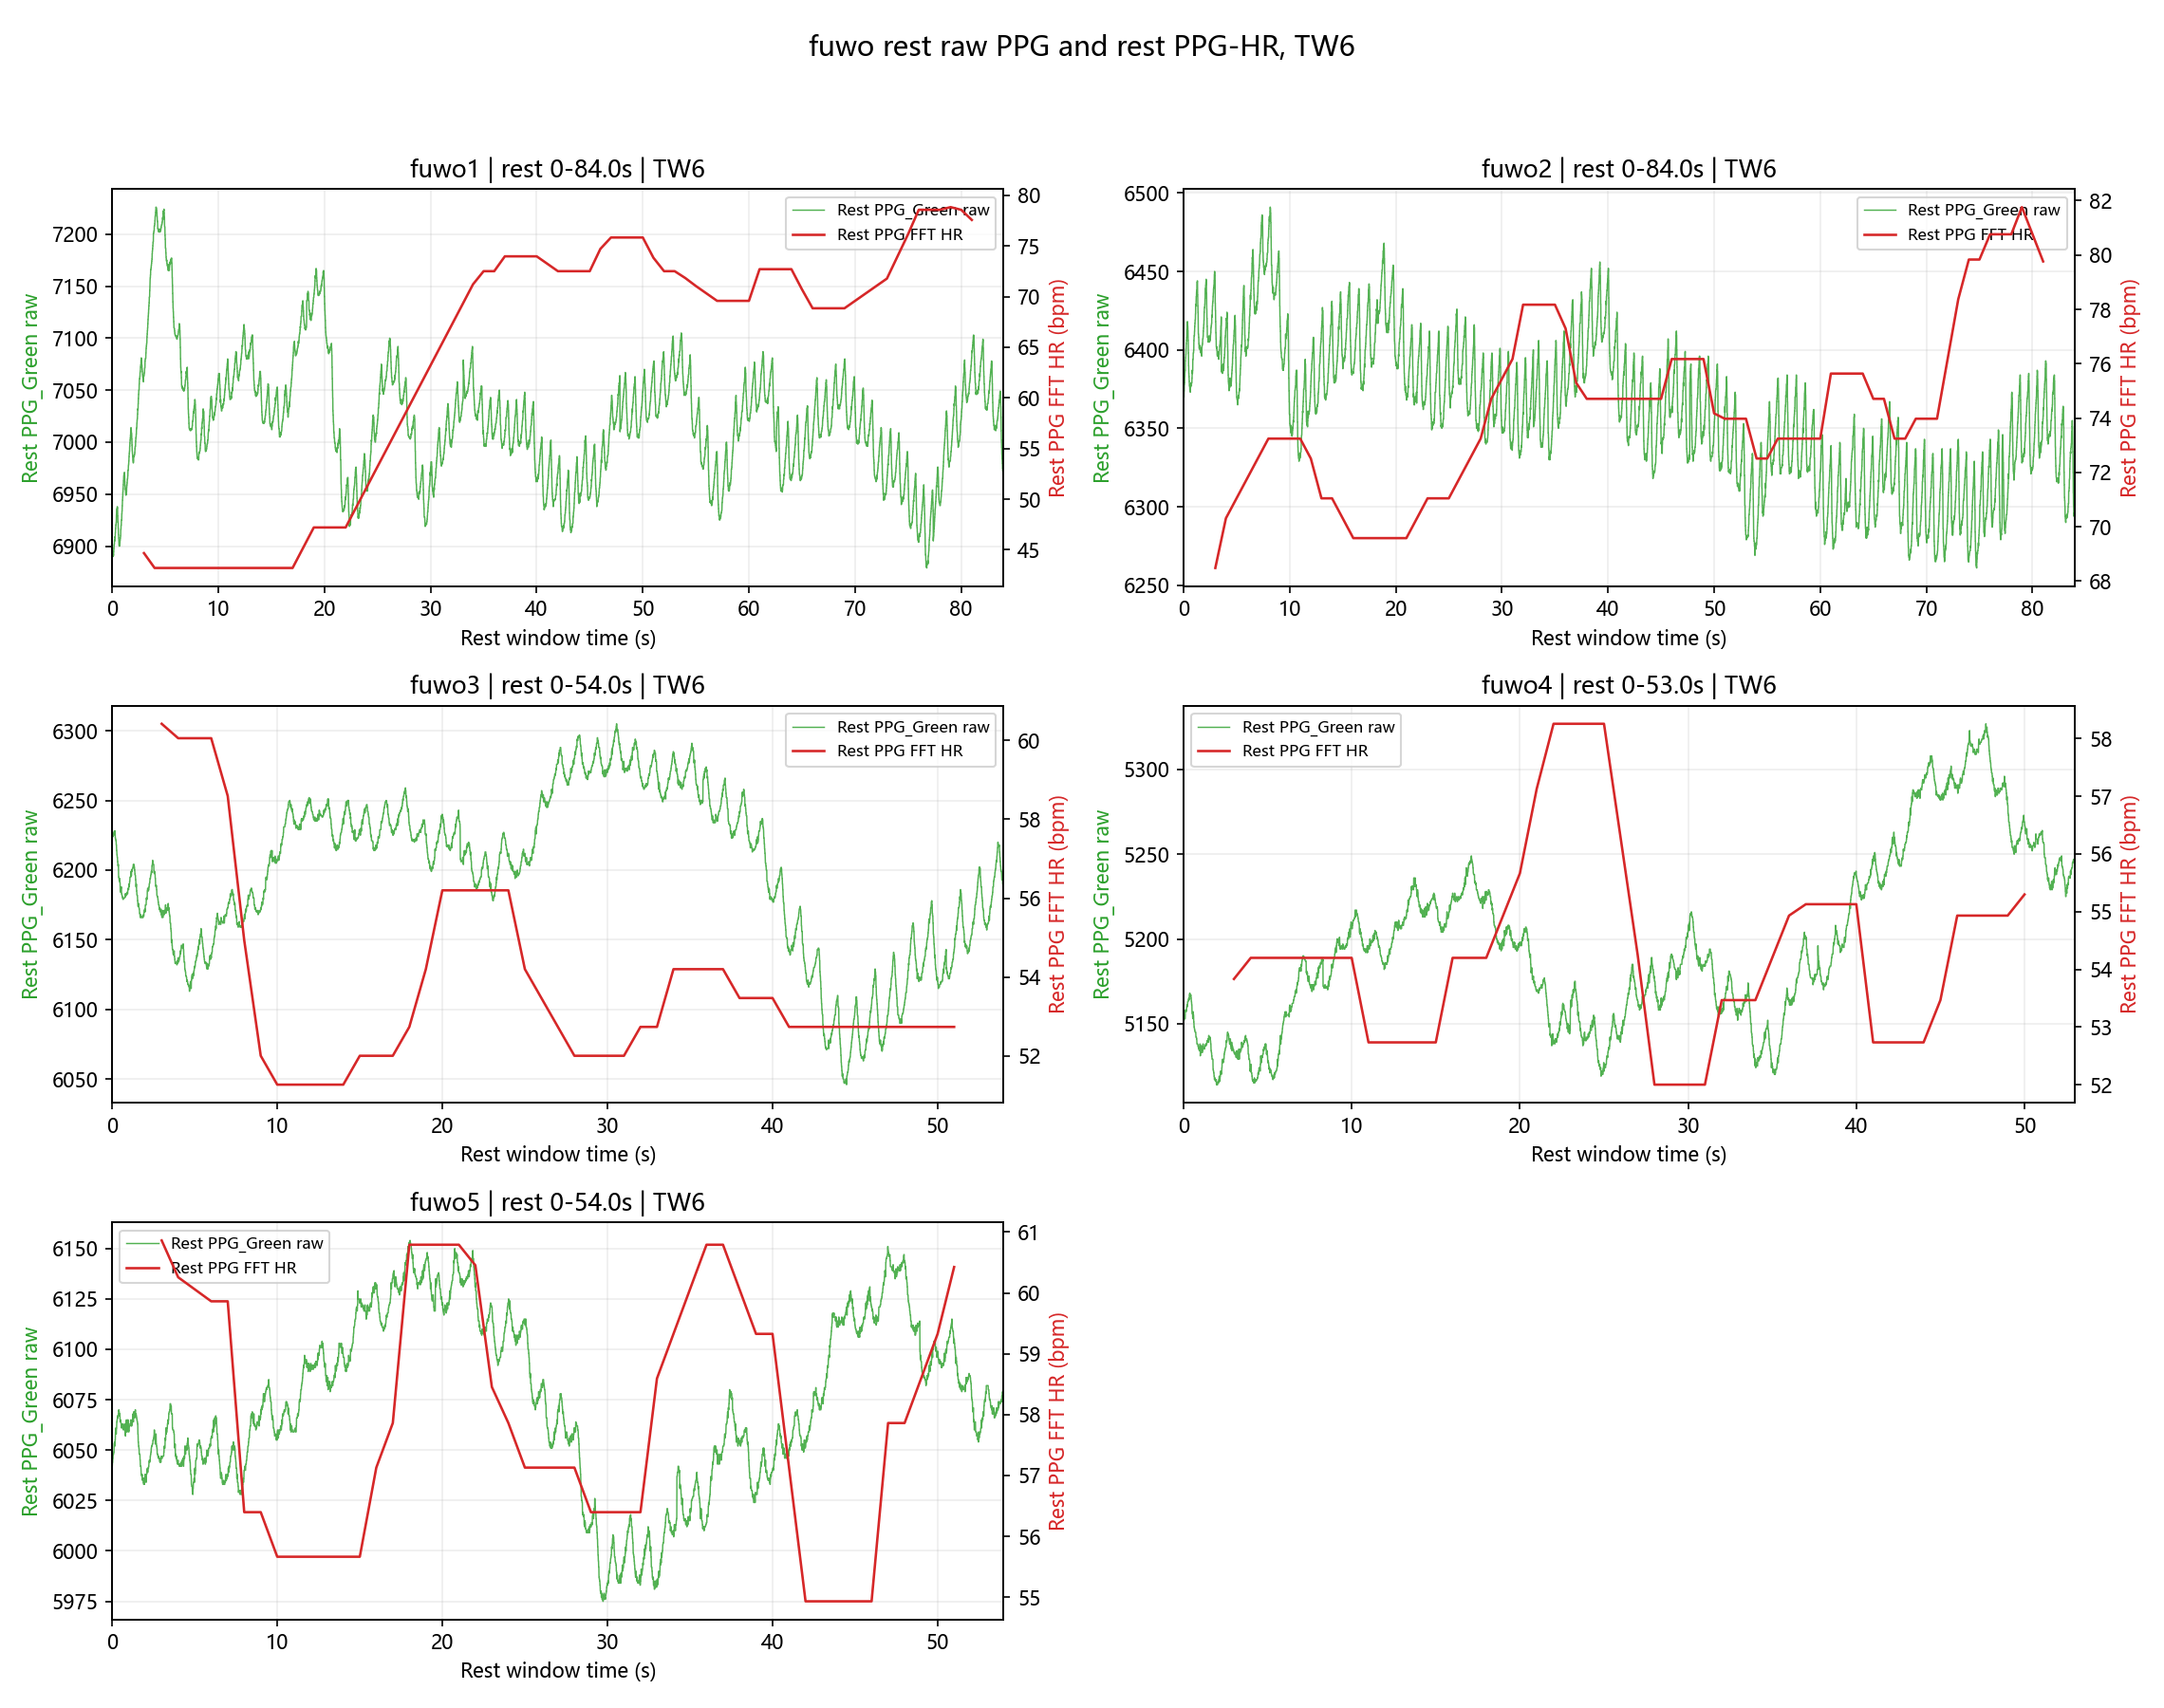

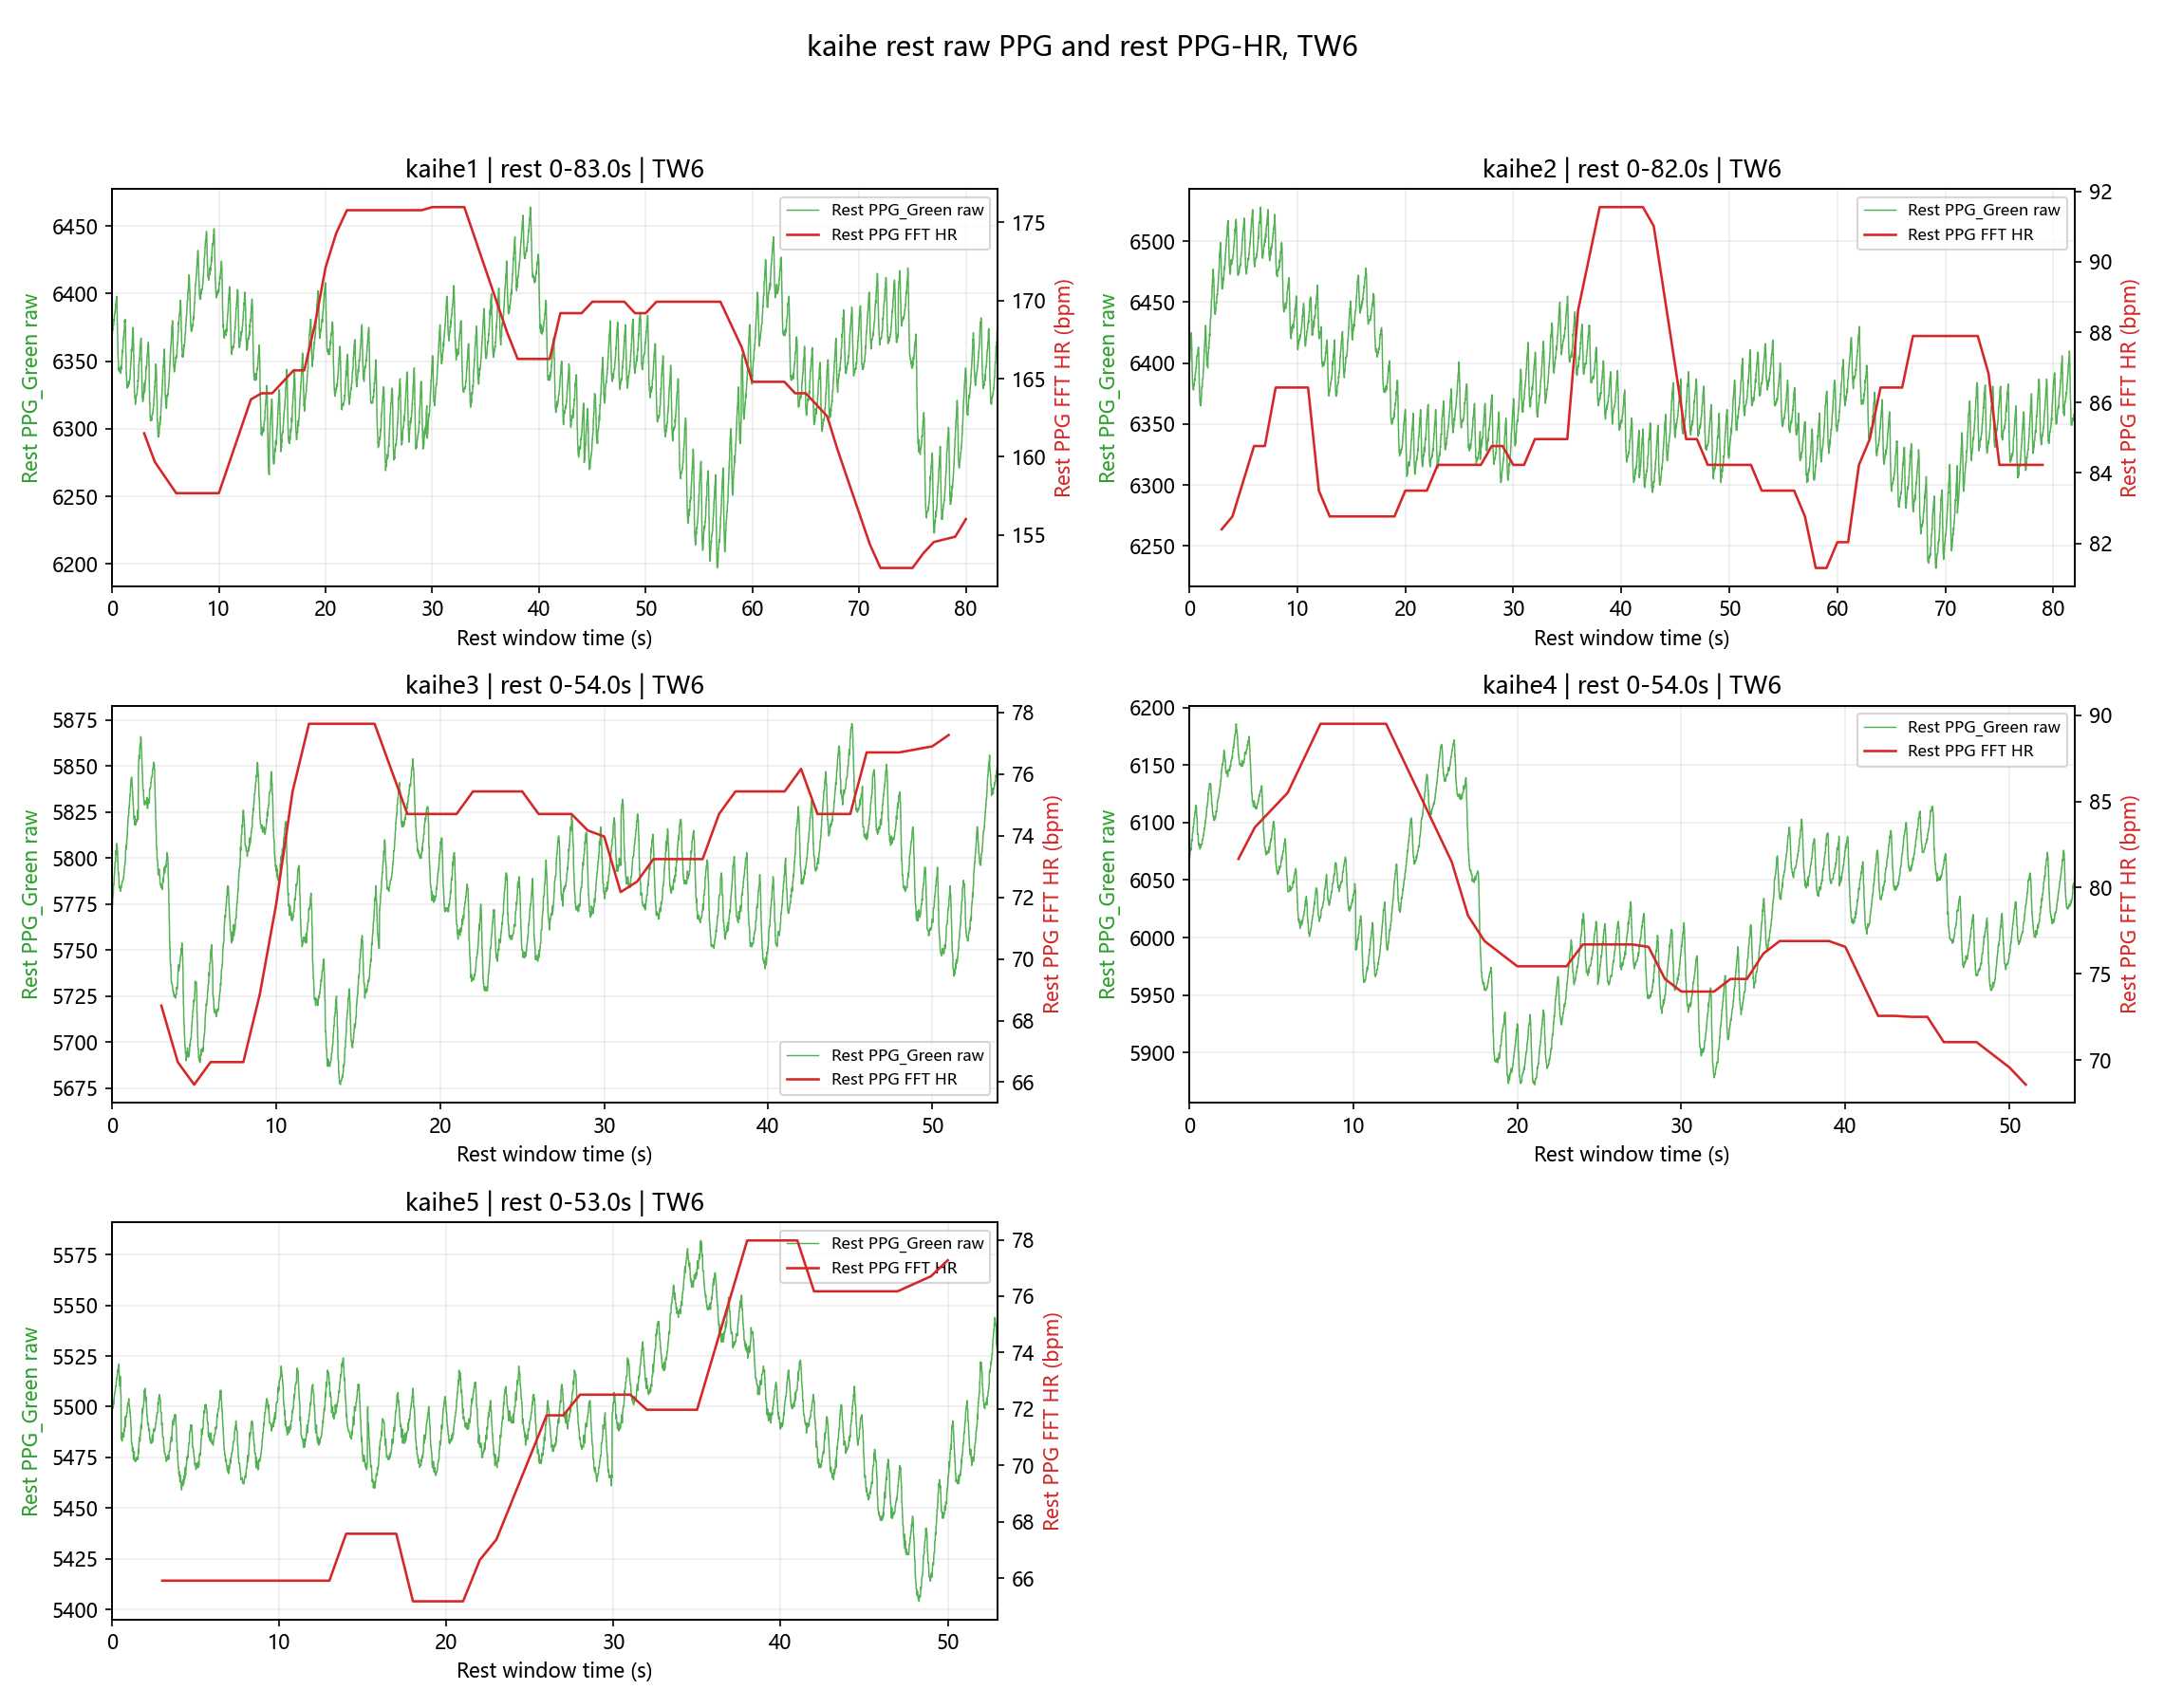

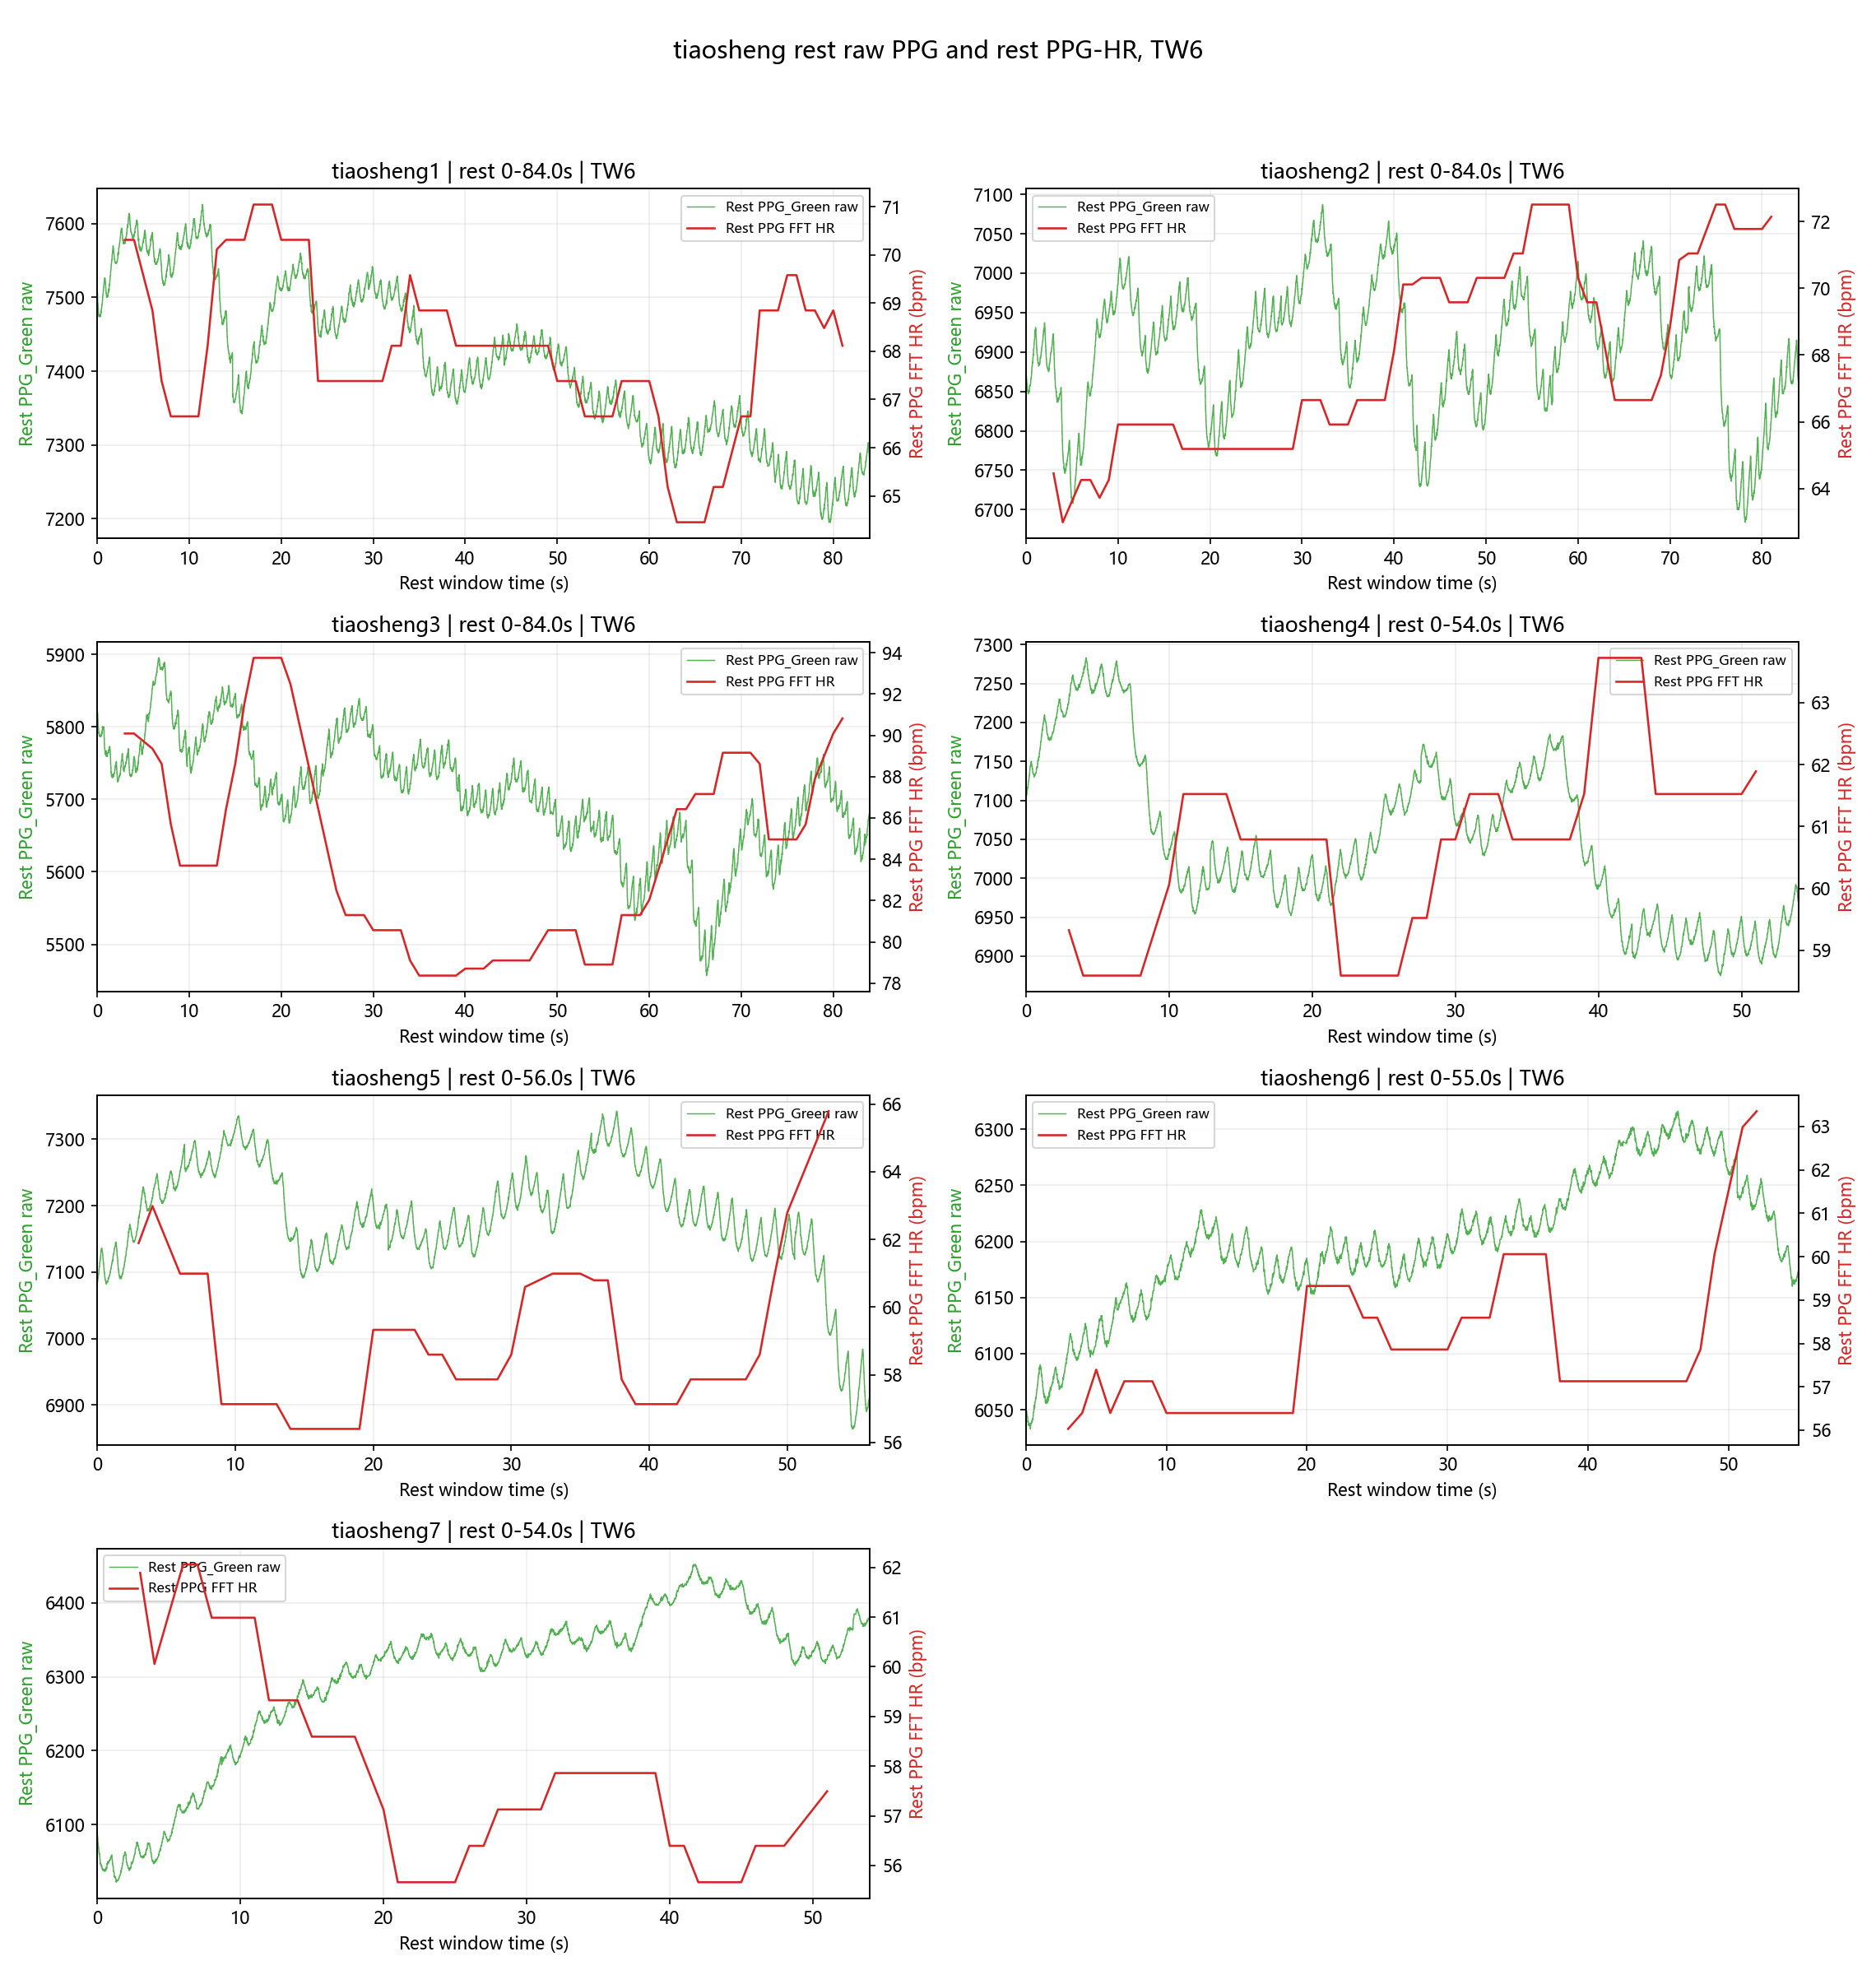

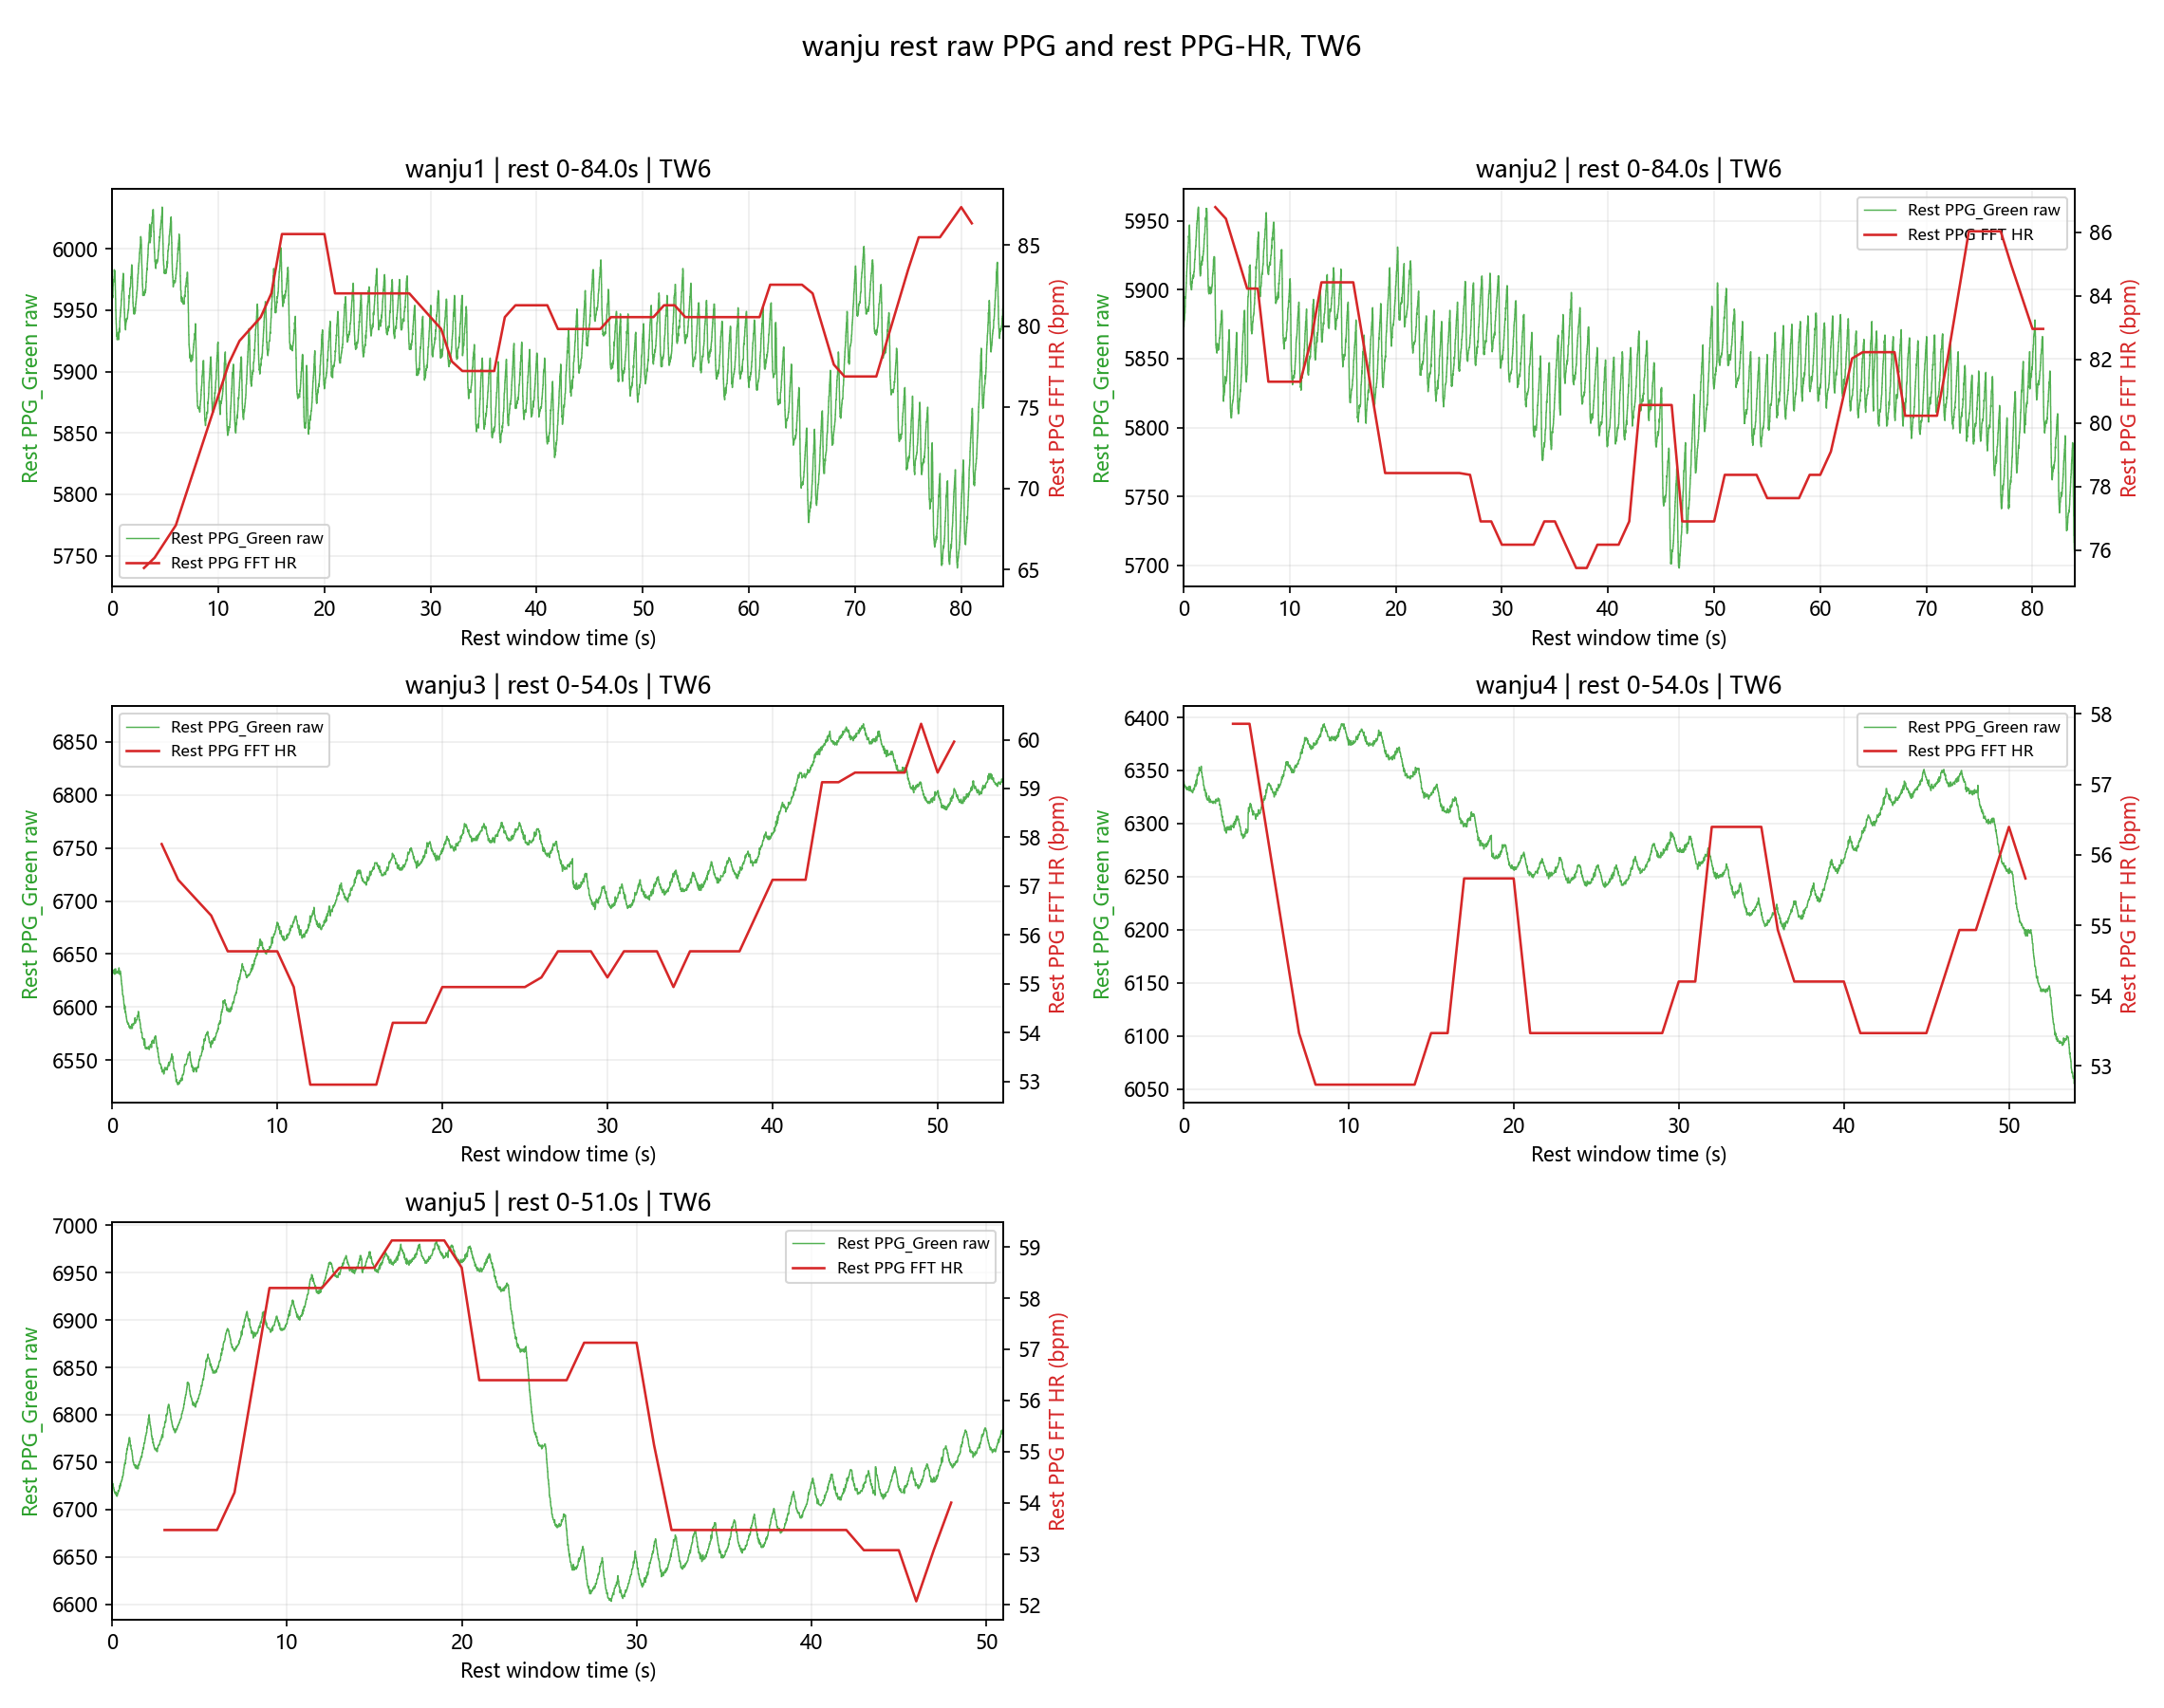

In [7]:
RAW_PPG_DUAL_AXIS_DIR = OUTPUT_ROOT / "allfield"
RAW_PPG_DUAL_AXIS_TW = int(ALIGNMENT_TW)

# 复用前面已经加载的数据集；如果 notebook 从本单元开始运行，则会自动补加载缺失样本。
raw_ppg_dual_axis_datasets = dict(
    globals().get("fullfield_ppg_hr_datasets", globals().get("alignment_diagnostic_datasets", {}))
)
for pair in good_pairs:
    if pair.motion_id in raw_ppg_dual_axis_datasets:
        continue
    try:
        raw_ppg_dual_axis_datasets[pair.motion_id] = load_and_preprocess_protocol(
            pair.sensor_csv,
            pair.ref_csv,
            fs_origin=FS_ORIGIN,
        )
    except Exception as exc:
        print(f"raw PPG dual-axis preprocessing failed: {pair.motion_id}: {exc}")

# 绘图函数内部只截取静息段 PPG，右轴 HR 使用第 0 单元的静息 HR 参数。
raw_ppg_dual_axis_paths = plot_raw_ppg_and_unaligned_hr_by_motion_type(
    pairs=good_pairs,
    datasets=raw_ppg_dual_axis_datasets,
    output_dir=RAW_PPG_DUAL_AXIS_DIR,
    fs_target=100,
    fs_origin=FS_ORIGIN,
    TW=RAW_PPG_DUAL_AXIS_TW,
    hr_band_hz=REST_HR_BAND_HZ,
    track_band_bpm=REST_HR_TRACK_BAND_BPM,
    slew_limit_bpm=REST_HR_SLEW_LIMIT_BPM,
    slew_step_bpm=REST_HR_SLEW_STEP_BPM,
    smooth_method=REST_HR_SMOOTH_METHOD,
    smooth_win=REST_HR_SMOOTH_WIN,
    peak_percent=REST_HR_PEAK_PERCENT,
    spec_penalty_enable=REST_HR_SPEC_PENALTY_ENABLE,
    spec_penalty_weight=REST_HR_SPEC_PENALTY_WEIGHT,
    spec_penalty_width_hz=REST_HR_SPEC_PENALTY_WIDTH_HZ,
)
print("raw_ppg_dual_axis_paths:", raw_ppg_dual_axis_paths)
for image_path in raw_ppg_dual_axis_paths.values():
    display(Image(filename=str(image_path)))


## 7. 训练单元 1：all_train 全样本拟合上限检查

`all_train` 会把每个运动类型的可用样本都作为训练集，用于观察模型在训练样本上的拟合上限。

解读建议：

- 如果 `all_train` 结果都不好，优先检查静息 Tdelay、PPG-HR 诊断图和滤波器参数范围。
- 如果 `all_train` 好但 LOGO 差，说明泛化能力不足，需要看目标域、cascade scheme 或搜索空间。


In [ ]:
# 正式运行时可使用较大的 n_trials；快速调试时建议改成 make_budgets(..., n_trials=1, n_repeats=1)。
ACTIVE_TARGET_SCOPES = ["motion_post10"]
ACTIVE_CASCADE_SCHEMES = ["ACC3", "HF2", "HF2_CF2", "HF2_ACC3"]
ACTIVE_ADAPTIVE_FILTERS = ["lms", "volterra", "rff_lms"]
CASCADE_TRAIN_BUDGETS = {
    "ACC3": {"n_trials": 200, "n_repeats": 2},
    "HF2": {"n_trials": 500, "n_repeats": 3},
    "HF2_CF2": {"n_trials": 500, "n_repeats": 3},
    "HF2_ACC3": {"n_trials": 500, "n_repeats": 2},
}
DELAY_ESTIMATION_MODE = "envelope"
OPTIMIZATION_OBJECTIVE = "accuracy"
DATA_SPLIT_MODE = "all_train"
VAL_GROUPS_PER_TYPE = 1
TEST_GROUPS_PER_TYPE = 1

result_all_train = run_training_cell(
    active_target_scopes=ACTIVE_TARGET_SCOPES,
    active_cascade_schemes=ACTIVE_CASCADE_SCHEMES,
    active_adaptive_filters=ACTIVE_ADAPTIVE_FILTERS,
    cascade_train_budgets=CASCADE_TRAIN_BUDGETS,
    optimization_objective=OPTIMIZATION_OBJECTIVE,
    data_split_mode=DATA_SPLIT_MODE,
    val_groups_per_type=VAL_GROUPS_PER_TYPE,
    test_groups_per_type=TEST_GROUPS_PER_TYPE,
    trial_param_overrides=REST_HR_TRIAL_OVERRIDES,
)


OUTPUT_RUN_NAME: motion_only-motion_recovery__ACC3-HF2-HF2_CF2-HF2_ACC3__lms-volterra-rff_lms__accuracy__all_train
RUN_OUTPUT_DIR: D:\python_notebook_base\outputs\motion_only-motion_recovery__ACC3-HF2-HF2_CF2-HF2_ACC3__lms-volterra-rff_lms__accuracy__all_train
trial_param_overrides: {'Alignment_TW': 6.0, 'Alignment_Step': 1.0, 'Rest_HR_Band_BPM': (40.0, 180.0), 'Rest_HR_Track_Band_BPM': 30.0, 'Rest_HR_Slew_Limit_BPM': 4.0, 'Rest_HR_Slew_Step_BPM': 2.0, 'Rest_HR_Smooth_Method': 'median', 'Rest_HR_Smooth_Win': 7, 'Rest_HR_Peak_Percent': 0.3, 'Rest_HR_Spec_Penalty_Enable': True, 'Rest_HR_Spec_Penalty_Weight': 0.2, 'Rest_HR_Spec_Penalty_Width_Hz': 0.2, 'Rest_Alignment_Score_Mode': 'aae', 'Enable_Time_Bias_After': True, 'Time_Bias_After_Range_S': (-5.0, 5.0), 'Time_Bias_After_Step_S': 1.0, 'Time_Bias_After_Mode': 'posthoc_oracle_alignment'}
配对总数: 28
未配对文件数量: 0
qc 1/28: multi_bobi1
qc 2/28: multi_bobi2
qc 3/28: multi_bobi3
qc 4/28: multi_bobi4
qc 5/28: multi_bobi5
qc 6/28: multi_bobi6
qc 7/2

: 

: 

## 8. 训练单元 2：leave-one-group-out 正式泛化评估

LOGO 会在每个运动类型内轮流留出一组作为 test，其余组作为 train，不使用 val。

最终测试指标会把所有 held-out test 窗口拼接后统一计算，而不是简单平均每个 fold 的指标。


In [ ]:
# LOGO 比 all_train 更接近正式泛化评估；运行时间通常更长。
ACTIVE_TARGET_SCOPES = ["motion_post10"]
ACTIVE_CASCADE_SCHEMES = ["ACC3", "HF2", "HF2_CF2", "HF2_ACC3"]
ACTIVE_ADAPTIVE_FILTERS = ["lms", "volterra", "rff_lms"]
# 快速 smoke test 可启用下一行：
# CASCADE_TRAIN_BUDGETS = make_budgets(ACTIVE_CASCADE_SCHEMES, n_trials=1, n_repeats=1)
CASCADE_TRAIN_BUDGETS = {
    "ACC3": {"n_trials": 200, "n_repeats": 2},
    "HF2": {"n_trials": 500, "n_repeats": 2},
    "HF2_CF2": {"n_trials": 500, "n_repeats": 2},
    "HF2_ACC3": {"n_trials": 500, "n_repeats": 2},
}
DELAY_ESTIMATION_MODE = "envelope"
OPTIMIZATION_OBJECTIVE = "accuracy"
DATA_SPLIT_MODE = "leave_one_group_out"

result_leave_one_group_out = run_training_cell(
    active_target_scopes=ACTIVE_TARGET_SCOPES,
    active_cascade_schemes=ACTIVE_CASCADE_SCHEMES,
    active_adaptive_filters=ACTIVE_ADAPTIVE_FILTERS,
    cascade_train_budgets=CASCADE_TRAIN_BUDGETS,
    optimization_objective=OPTIMIZATION_OBJECTIVE,
    data_split_mode=DATA_SPLIT_MODE,
    trial_param_overrides=REST_HR_TRIAL_OVERRIDES,
)


## 9. 训练单元 3：完整 63 模式连通性检查

该单元用于检查完整组合是否能跑通：3 个 target_scope × 7 个 cascade_scheme × 3 个 filter = 63 种模式。

默认关闭，避免误触发长时间运行。


In [ ]:
RUN_FULL_63_MODE_TEST = False

if RUN_FULL_63_MODE_TEST:
    # 完整组合建议先用 1 trial / 1 repeat 做连通性测试，再提高预算。
    ACTIVE_TARGET_SCOPES = ["motion_only", "motion_recovery", "motion_post10"]
    ACTIVE_CASCADE_SCHEMES = ["ACC3", "HF2", "CF2", "HF2_CF2", "CF2_HF2", "ACC3_HF2", "HF2_ACC3"]
    ACTIVE_ADAPTIVE_FILTERS = ["lms", "volterra", "rff_lms"]
    CASCADE_TRAIN_BUDGETS = make_budgets(ACTIVE_CASCADE_SCHEMES, n_trials=1, n_repeats=1)
    OPTIMIZATION_OBJECTIVE = "accuracy"
    DATA_SPLIT_MODE = "split"
    VAL_GROUPS_PER_TYPE = 1
    TEST_GROUPS_PER_TYPE = 1
    result_full_63 = run_training_cell(
        active_target_scopes=ACTIVE_TARGET_SCOPES,
        active_cascade_schemes=ACTIVE_CASCADE_SCHEMES,
        active_adaptive_filters=ACTIVE_ADAPTIVE_FILTERS,
        cascade_train_budgets=CASCADE_TRAIN_BUDGETS,
        optimization_objective=OPTIMIZATION_OBJECTIVE,
        data_split_mode=DATA_SPLIT_MODE,
        val_groups_per_type=VAL_GROUPS_PER_TYPE,
        test_groups_per_type=TEST_GROUPS_PER_TYPE,
        trial_param_overrides=REST_HR_TRIAL_OVERRIDES,
    )
else:
    print("RUN_FULL_63_MODE_TEST=False，已跳过完整 63 模式测试。")


## 10. 输出检查

本部分自动选择最近一次结果对象：

`result_leave_one_group_out -> result_all_train -> result_split`

然后检查 batch summary、每个 motion_type 的 split/fold 文件、mode summary、bayes curve data 和 final summary。


In [ ]:
RESULT_TO_CHECK = globals().get("result_leave_one_group_out", globals().get("result_all_train", globals().get("result_split", None)))
if RESULT_TO_CHECK is None:
    print("没有可检查的训练结果，请先运行 all_train 或 LOGO 训练单元。")
else:
    print("output_root:", RESULT_TO_CHECK.output_root)
    print("qc_tables:", RESULT_TO_CHECK.qc_tables)
    print("batch_summary:", RESULT_TO_CHECK.batch_summary_csv)
    if RESULT_TO_CHECK.batch_summary_csv and Path(RESULT_TO_CHECK.batch_summary_csv).exists():
        display(pd.read_csv(RESULT_TO_CHECK.batch_summary_csv))

    # 逐个运动类型检查关键 CSV 和贝叶斯曲线，确认输出结构是否完整。
    for motion_type, motion_dir in RESULT_TO_CHECK.motion_type_dirs.items():
        print("motion_type:", motion_type, motion_dir)
        for name in ["split_files.csv", "fold_split_files.csv", "mode_summary_aae.csv", "mode_summary_accuracy.csv", "fold_summary_aae.csv", "bayes_curve_data.csv"]:
            path = motion_dir / name
            print(name, path.exists(), path)
            if path.exists():
                display(pd.read_csv(path).head())
        curve_png = motion_dir / "bayes_curve.png"
        if curve_png.exists():
            display(Image(filename=str(curve_png)))

    # final_summary 是跨运动类型的汇总表，LOGO 模式下应反映所有 held-out 窗口拼接后的测试指标。
    for key, path in RESULT_TO_CHECK.final_summary_tables.items():
        print(key, path)
        if Path(path).exists():
            display(pd.read_csv(path).head())


## 11. 手动重画 best_params HR 曲线

本部分用于在已有 `best_params_<filter>.csv` 基础上，手动重画某个样本的 HR 曲线。

用途：

- 单独检查某个样本的 adaptive HR 曲线。
- 对比参考 HR、baseline FFT HR 和 adaptive HR。
- LOGO 模式下如果 best_params 有多 fold，可以通过 `fold_id` 或 `heldout_group_id` 指定行。


In [ ]:
RUN_MANUAL_REDRAW = True

# 请按需要修改样本 CSV、参考 HR CSV、目标模式和 best_params CSV 路径。
SENSOR_CSV_PATH = TESTDATA_DIR / "multi_tiaosheng1.csv"
REF_CSV_PATH = TESTDATA_DIR / "multi_tiaosheng1_ref.csv"
TARGET_SCOPE = "motion_only"
CASCADE_SCHEME = "ACC3"
ADAPTIVE_FILTER = "lms"
BEST_PARAM_CSV_PATH = "D:/python_notebook_base/outputs/motion_only-motion_recovery-motion_post10__ACC3-HF2-CF2-HF2_CF2-CF2_HF2-ACC3_HF2-HF2_ACC3__lms-volterra-rff_lms__accuracy__split__run01/motion_types/tiaosheng/best_params_lms.csv"
OUTPUT_DIR = OUTPUT_ROOT / "manual_redraw"

if RUN_MANUAL_REDRAW:
    manual_paths = redraw_best_param_hr_curves(
        sensor_csv_path=SENSOR_CSV_PATH,
        ref_csv_path=REF_CSV_PATH,
        target_scope=TARGET_SCOPE,
        cascade_scheme=CASCADE_SCHEME,
        adaptive_filter=ADAPTIVE_FILTER,
        best_param_csv_path=BEST_PARAM_CSV_PATH,
        output_dir=OUTPUT_DIR,
        fs_origin=FS_ORIGIN,
        enable_time_bias_after=ENABLE_TIME_BIAS_AFTER,
        time_bias_after_range_s=TIME_BIAS_AFTER_RANGE_S,
        time_bias_after_step_s=TIME_BIAS_AFTER_STEP_S,
        time_bias_after_mode=TIME_BIAS_AFTER_MODE,
        # LOGO best_params 可能一组运动有多行；需要时取消注释指定某个 fold。
        # fold_id=0,
        # heldout_group_id="tiaosheng1",
    )
    print(manual_paths)
    for image_path in manual_paths.values():
        if Path(image_path).suffix.lower() in {".png", ".jpg", ".jpeg"}:
            display(Image(filename=str(image_path)))
else:
    print("RUN_MANUAL_REDRAW=False；如需手动重画，请确认 BEST_PARAM_CSV_PATH 后改为 True。")
